In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

### Create Dataframe

In [91]:
file_paths_ordered = ["2010.csv", "2011.csv", "2012.csv", "2013.csv", "2014.csv", "2015.csv", "2016.csv", "2017.csv", "2018.csv", "2019.csv", "2020.csv", "2021.csv", "2022.csv", "2023.csv", "2024.csv", "2025.csv", "2026.csv"]

df_list = [pd.read_csv(file) for file in file_paths_ordered]
match_df = pd.concat(df_list, ignore_index=True)


match_df["tourney_date"] = pd.to_datetime(match_df["tourney_date"].astype(str),
    format="%Y%m%d"
)
match_df = match_df.sort_values(
    ["tourney_date", "tourney_id", "match_num"]
).reset_index(drop=True)

match_df[["tourney_date", "tourney_name", "surface", "winner_name", "loser_name", "score", "round"]].tail(20)



,tourney_date,tourney_name,surface,winner_name,loser_name,score,round
47116,2026-06-18,Queen's Club,Grass,Rinky Hijikata,Jiri Lehecka,4-6 7-5 7-6(7),R16
47117,2026-06-18,Halle,Grass,Ben Shelton,Ethan Quinn,6-4 5-7 6-4,R16
47118,2026-06-18,Halle,Grass,Taylor Fritz,Fabian Marozsan,6-2 6-4,R16
47119,2026-06-18,Halle,Grass,Alexander Zverev,Yannick Hanfmann,6-3 7-6(4),R16
47120,2026-06-18,Halle,Grass,Raphael Collignon,Mattia Bellucci,4-6 6-4 6-3,R16
47121,2026-06-19,Queen's Club,Grass,Brandon Nakashima,Alex de Minaur,7-5 6-3,QF
47122,2026-06-19,Queen's Club,Grass,Ugo Humbert,Hamad Medjedovic,2-6 7-6(4) 7-6(5),R16
47123,2026-06-19,Queen's Club,Grass,Francisco Cerundolo,Arthur Fery,7-6(1) 3-6 6-4,QF
47124,2026-06-19,Queen's Club,Grass,Ugo Humbert,Rinky Hijikata,6-1 6-2,QF
47125,2026-06-19,Queen's Club,Grass,Tommy Paul,Alejandro Davidovich Fokina,6-3 7-6(4),QF


## Feature Engineering

### Simple ELO Function

$P$(A beats B) = $\frac{1}{{1+10^{{(R_B - R_A)}/400}}}$

In [92]:
def expected_win_prob(rating_a, rating_b):
    return 1/(1+10**((rating_b-rating_a)/400))

def add_simple_elo_features(df, k=32, start_elo=1500):
    """
    Adds pre-match Elo ratings for winner and loser.
    
    Parameters:
        df: match dataframe sorted chronologically
        k: Elo update speed
        start_elo: rating assigned to players when first seen
    
    Returns:
        df with w_elo_pre and l_elo_pre columns
    """
    
    df = df.copy()
    
    # Stores current Elo rating for each player
    ratings = {}
    
    # Lists to store pre-match ratings
    w_elo_pre = []
    l_elo_pre = []
    
    for _, row in df.iterrows():
        winner = row["winner_id"]
        loser = row["loser_id"]
        
        # Get current ratings, or assign start_elo if player has never appeared
        winner_rating = ratings.get(winner, start_elo)
        loser_rating = ratings.get(loser, start_elo)
        
        # Store pre-match ratings
        w_elo_pre.append(winner_rating)
        l_elo_pre.append(loser_rating)
        
        # Expected probability that the winner would beat the loser
        expected_winner = expected_win_prob(winner_rating, loser_rating)
        expected_loser = 1 - expected_winner
        
        # Update ratings after the match
        ratings[winner] = winner_rating + k * (1 - expected_winner)
        ratings[loser] = loser_rating + k * (0 - expected_loser)
    
    df["w_elo_pre"] = w_elo_pre
    df["l_elo_pre"] = l_elo_pre
    
    return df

In [93]:
match_df = add_simple_elo_features(match_df, k=32, start_elo = 1500)

match_df[["tourney_date", "tourney_name", "winner_name", "loser_name", "w_elo_pre", "l_elo_pre"]]

,tourney_date,tourney_name,winner_name,loser_name,w_elo_pre,l_elo_pre
0,2010-01-03,Brisbane,Andy Roddick,Peter Luczak,1500.000000,1500.000000
1,2010-01-03,Brisbane,Carsten Ball,Mischa Zverev,1500.000000,1500.000000
2,2010-01-03,Brisbane,Richard Gasquet,Jarkko Nieminen,1500.000000,1500.000000
3,2010-01-03,Brisbane,Matthew Ebden,Jurgen Melzer,1500.000000,1500.000000
4,2010-01-03,Brisbane,Tomas Berdych,Nick Lindahl,1500.000000,1500.000000
...,...,...,...,...,...,...
47131,2026-06-20,Queen's Club,Tommy Paul,Ugo Humbert,1871.582183,1737.294883
47132,2026-06-20,Halle,Taylor Fritz,Alexander Zverev,1832.619632,2033.291388
47133,2026-06-20,Halle,Frances Tiafoe,Daniel Altmaier,1808.059551,1629.038262
47134,2026-06-21,Queen's Club,Francisco Cerundolo,Tommy Paul,1806.217218,1881.688622


### Surface ELO Function

In [94]:
def add_surface_elo_features(df, k=32, start_elo=1500):
    """
    Adds pre-match surface-specific Elo ratings.

    Each player has a separate Elo rating for each surface.
    For example, a player's grass Elo is tracked separately from clay Elo.

    The pre-match ratings are recorded before updating with the current match,
    which prevents leakage.
    """
    
    df = df.copy()
    
    surface_ratings = {}
    
    w_surface_elo_pre = []
    l_surface_elo_pre = []
    
    for _, row in df.iterrows():
        winner = row["winner_id"]
        loser = row["loser_id"]
        surface = row["surface"]
        
        if pd.isna(surface):
            surface = "Unknown"
        
        winner_key = (winner, surface)
        loser_key = (loser, surface)
        
        winner_rating = surface_ratings.get(winner_key, start_elo)
        loser_rating = surface_ratings.get(loser_key, start_elo)
        
        w_surface_elo_pre.append(winner_rating)
        l_surface_elo_pre.append(loser_rating)
        
        p_winner = expected_win_prob(winner_rating, loser_rating)
        elo_change = k * (1 - p_winner)
        
        surface_ratings[winner_key] = winner_rating + elo_change
        surface_ratings[loser_key] = loser_rating - elo_change
    
    df["w_surface_elo_pre"] = w_surface_elo_pre
    df["l_surface_elo_pre"] = l_surface_elo_pre
    
    return df

In [95]:
match_df = add_surface_elo_features(match_df, k=32, start_elo=1500)
match_df[[
    "surface",
    "winner_name",
    "loser_name",
    "w_elo_pre",
    "l_elo_pre",
    "w_surface_elo_pre",
    "l_surface_elo_pre"
]].tail(10)

,surface,winner_name,loser_name,w_elo_pre,l_elo_pre,w_surface_elo_pre,l_surface_elo_pre
47126,Grass,Alexander Zverev,Raphael Collignon,2029.189386,1696.158527,1699.229463,1526.002348
47127,Grass,Taylor Fritz,Ben Shelton,1814.792663,1854.638564,1777.379753,1650.613310
47128,Grass,Daniel Altmaier,Daniil Medvedev,1602.062651,1894.017881,1476.353094,1727.058975
47129,Grass,Frances Tiafoe,Felix Auger-Aliassime,1789.088752,1854.355889,1601.049337,1613.898130
47130,Grass,Francisco Cerundolo,Brandon Nakashima,1793.430977,1722.683187,1525.652629,1637.005421
47131,Grass,Tommy Paul,Ugo Humbert,1871.582183,1737.294883,1676.527121,1604.324814
47132,Grass,Taylor Fritz,Alexander Zverev,1832.619632,2033.291388,1787.787906,1707.853371
47133,Grass,Frances Tiafoe,Daniel Altmaier,1808.059551,1629.038262,1617.640776,1502.239381
47134,Grass,Francisco Cerundolo,Tommy Paul,1806.217218,1881.688622,1546.611960,1689.249135
47135,Grass,Frances Tiafoe,Taylor Fritz,1816.474959,1856.954098,1628.513527,1800.170388


### Score-Adjusted ELO

#### Parse Match Scores

In [96]:
import re

def parse_tennis_score(score):
    """
    Parses a tennis score from the winner's perspective.

    Returns:
        winner_sets, loser_sets, winner_games, loser_games, valid_score
    """
    
    if pd.isna(score):
        return np.nan, np.nan, np.nan, np.nan, False
    
    score = str(score).strip()
    score_upper = score.upper()
    
    # Remove matches that were not completed normally
    bad_tokens = ["RET", "W/O", "DEF", "ABD", "DEF."]
    
    if any(token in score_upper for token in bad_tokens):
        return np.nan, np.nan, np.nan, np.nan, False
    
    # Remove tiebreak info in parentheses, e.g. 7-6(5) -> 7-6
    clean_score = re.sub(r"\([^)]*\)", "", score)
    
    sets = clean_score.split()
    
    winner_sets = 0
    loser_sets = 0
    winner_games = 0
    loser_games = 0
    
    for s in sets:
        if "-" not in s:
            continue
        
        parts = s.split("-")
        
        if len(parts) < 2:
            continue
        
        try:
            w_games = int(parts[0])
            l_games = int(parts[1])
        except ValueError:
            continue
        
        winner_games += w_games
        loser_games += l_games
        
        if w_games > l_games:
            winner_sets += 1
        elif l_games > w_games:
            loser_sets += 1
    
    if winner_games + loser_games == 0:
        return np.nan, np.nan, np.nan, np.nan, False
    
    return winner_sets, loser_sets, winner_games, loser_games, True

In [97]:
score_parsed = match_df["score"].apply(parse_tennis_score)

match_df[[
    "winner_sets",
    "loser_sets",
    "winner_games",
    "loser_games",
    "valid_score"
]] = pd.DataFrame(score_parsed.tolist(), index=match_df.index)

#### Score-Margin Variables

In [98]:
match_df["winner_game_pct"] = (
    match_df["winner_games"] / 
    (match_df["winner_games"] + match_df["loser_games"])
)

match_df["game_diff"] = (
    match_df["winner_games"] - match_df["loser_games"]
)

match_df["set_diff"] = (
    match_df["winner_sets"] - match_df["loser_sets"]
)

#### Score Multiplier

In [99]:
def score_margin_multiplier(winner_game_pct):
    """
    Converts winner game percentage into a multiplier for Elo updates.
    
    Close wins get a smaller update.
    Dominant wins get a larger update.
    The multiplier is capped to avoid extreme changes.
    """
    
    if pd.isna(winner_game_pct):
        return 1.0
    
    mult = 1 + 1.5 * (winner_game_pct - 0.60)
    
    # Cap multiplier between 0.75 and 1.50
    mult = max(0.75, min(1.50, mult))
    
    return mult

In [100]:
match_df["score_margin_mult"] = (
    match_df["winner_game_pct"].apply(score_margin_multiplier)
)

#### Score-adjusted ELO and Score-adjusted surface ELO

In [101]:
def add_score_adjusted_elo_features(df, k=32, start_elo=1500):
    """
    Adds pre-match score-adjusted Elo and score-adjusted surface Elo.

    The current match score is used only after recording pre-match ratings,
    so the features remain leakage-safe.
    """
    
    df = df.copy()
    
    overall_ratings = {}
    surface_ratings = {}
    
    w_score_elo_pre = []
    l_score_elo_pre = []
    
    w_score_surface_elo_pre = []
    l_score_surface_elo_pre = []
    
    for _, row in df.iterrows():
        winner = row["winner_id"]
        loser = row["loser_id"]
        surface = row["surface"]
        
        if pd.isna(surface):
            surface = "Unknown"
        
        margin_mult = row.get("score_margin_mult", 1.0)
        
        if pd.isna(margin_mult):
            margin_mult = 1.0
        
        # Overall score-adjusted Elo
        winner_rating = overall_ratings.get(winner, start_elo)
        loser_rating = overall_ratings.get(loser, start_elo)
        
        w_score_elo_pre.append(winner_rating)
        l_score_elo_pre.append(loser_rating)
        
        p_winner = expected_win_prob(winner_rating, loser_rating)
        elo_change = k * margin_mult * (1 - p_winner)
        
        overall_ratings[winner] = winner_rating + elo_change
        overall_ratings[loser] = loser_rating - elo_change
        
        # Surface score-adjusted Elo
        winner_key = (winner, surface)
        loser_key = (loser, surface)
        
        winner_surface_rating = surface_ratings.get(winner_key, start_elo)
        loser_surface_rating = surface_ratings.get(loser_key, start_elo)
        
        w_score_surface_elo_pre.append(winner_surface_rating)
        l_score_surface_elo_pre.append(loser_surface_rating)
        
        p_winner_surface = expected_win_prob(
            winner_surface_rating,
            loser_surface_rating
        )
        
        surface_elo_change = k * margin_mult * (1 - p_winner_surface)
        
        surface_ratings[winner_key] = winner_surface_rating + surface_elo_change
        surface_ratings[loser_key] = loser_surface_rating - surface_elo_change
    
    df["w_score_elo_pre"] = w_score_elo_pre
    df["l_score_elo_pre"] = l_score_elo_pre
    
    df["w_score_surface_elo_pre"] = w_score_surface_elo_pre
    df["l_score_surface_elo_pre"] = l_score_surface_elo_pre
    
    return df

In [102]:
match_df = add_score_adjusted_elo_features(match_df, k=32, start_elo=1500)

### Rolling Recent Form

In [103]:
def add_rolling_form_features(df, windows=[10, 20]):
    """
    Adds pre-match rolling form features.

    For each player before each match:
    - overall win percentage in last N matches
    - number of previous matches in last N window
    - surface-specific win percentage in last N surface matches
    - number of previous surface matches in last N window

    The current match is added to history only after pre-match features are recorded.
    """
    
    df = df.copy()
    
    player_history = {}
    player_surface_history = {}
    
    new_cols = {}
    
    for window in windows:
        new_cols[f"w_last{window}_win_pct_pre"] = []
        new_cols[f"l_last{window}_win_pct_pre"] = []
        new_cols[f"w_last{window}_matches_pre"] = []
        new_cols[f"l_last{window}_matches_pre"] = []
        
        new_cols[f"w_surface_last{window}_win_pct_pre"] = []
        new_cols[f"l_surface_last{window}_win_pct_pre"] = []
        new_cols[f"w_surface_last{window}_matches_pre"] = []
        new_cols[f"l_surface_last{window}_matches_pre"] = []
    
    for _, row in df.iterrows():
        winner = row["winner_id"]
        loser = row["loser_id"]
        surface = row["surface"]
        
        if pd.isna(surface):
            surface = "Unknown"
        
        for window in windows:
            # Overall recent form
            w_hist = player_history.get(winner, [])
            l_hist = player_history.get(loser, [])
            
            w_recent = w_hist[-window:]
            l_recent = l_hist[-window:]
            
            w_win_pct = np.mean(w_recent) if len(w_recent) > 0 else 0.5
            l_win_pct = np.mean(l_recent) if len(l_recent) > 0 else 0.5
            
            new_cols[f"w_last{window}_win_pct_pre"].append(w_win_pct)
            new_cols[f"l_last{window}_win_pct_pre"].append(l_win_pct)
            new_cols[f"w_last{window}_matches_pre"].append(len(w_recent))
            new_cols[f"l_last{window}_matches_pre"].append(len(l_recent))
            
            # Surface-specific recent form
            w_surface_hist = player_surface_history.get((winner, surface), [])
            l_surface_hist = player_surface_history.get((loser, surface), [])
            
            w_surface_recent = w_surface_hist[-window:]
            l_surface_recent = l_surface_hist[-window:]
            
            w_surface_win_pct = (
                np.mean(w_surface_recent) if len(w_surface_recent) > 0 else 0.5
            )
            l_surface_win_pct = (
                np.mean(l_surface_recent) if len(l_surface_recent) > 0 else 0.5
            )
            
            new_cols[f"w_surface_last{window}_win_pct_pre"].append(w_surface_win_pct)
            new_cols[f"l_surface_last{window}_win_pct_pre"].append(l_surface_win_pct)
            new_cols[f"w_surface_last{window}_matches_pre"].append(len(w_surface_recent))
            new_cols[f"l_surface_last{window}_matches_pre"].append(len(l_surface_recent))
        
        # Update histories after recording pre-match features
        player_history.setdefault(winner, []).append(1)
        player_history.setdefault(loser, []).append(0)
        
        player_surface_history.setdefault((winner, surface), []).append(1)
        player_surface_history.setdefault((loser, surface), []).append(0)
    
    for col, values in new_cols.items():
        df[col] = values
    
    return df

In [104]:
match_df = add_rolling_form_features(match_df, windows=[10, 20])

## Create Neutral Dataset
The raw data is stored as winner and loser columns, but a model cannot be trained directly on that structure because the winner is already encoded in the column names. To avoid this, I randomly assign each match's winner or loser to Player A and the other player to Player B. The target variable is whether Player A won. This creates a fair prediction problem where the model must learn from pre-match differences rather than column labels. 

### Create Neutral Dataset

In [105]:
def create_neutral_match_dataset(match_df, seed=42):
    """
    Converts winner/loser match data into neutral Player A / Player B format.

    Player A is randomly assigned to be either the winner or loser.
    The target A_won equals 1 if Player A won, 0 otherwise.
    """
    
    rng = np.random.default_rng(seed)
    winner_is_A = rng.random(len(match_df)) < 0.5
    
    neutral_df = pd.DataFrame({
        "date": match_df["tourney_date"],
        "tourney_id": match_df["tourney_id"],
        "tourney_name": match_df["tourney_name"],
        "surface": match_df["surface"],
        "draw_size": match_df["draw_size"],
        "tourney_level": match_df["tourney_level"],
        "indoor": match_df["indoor"],
        "round": match_df["round"],
        "best_of": match_df["best_of"],
        
        # Player A basic info
        "player_A_id": np.where(winner_is_A, match_df["winner_id"], match_df["loser_id"]),
        "player_A_name": np.where(winner_is_A, match_df["winner_name"], match_df["loser_name"]),
        "player_A_rank": np.where(winner_is_A, match_df["winner_rank"], match_df["loser_rank"]),
        "player_A_rank_points": np.where(winner_is_A, match_df["winner_rank_points"], match_df["loser_rank_points"]),
        "player_A_age": np.where(winner_is_A, match_df["winner_age"], match_df["loser_age"]),
        "player_A_ht": np.where(winner_is_A, match_df["winner_ht"], match_df["loser_ht"]),
        "player_A_hand": np.where(winner_is_A, match_df["winner_hand"], match_df["loser_hand"]),
        
        # Player B basic info
        "player_B_id": np.where(winner_is_A, match_df["loser_id"], match_df["winner_id"]),
        "player_B_name": np.where(winner_is_A, match_df["loser_name"], match_df["winner_name"]),
        "player_B_rank": np.where(winner_is_A, match_df["loser_rank"], match_df["winner_rank"]),
        "player_B_rank_points": np.where(winner_is_A, match_df["loser_rank_points"], match_df["winner_rank_points"]),
        "player_B_age": np.where(winner_is_A, match_df["loser_age"], match_df["winner_age"]),
        "player_B_ht": np.where(winner_is_A, match_df["loser_ht"], match_df["winner_ht"]),
        "player_B_hand": np.where(winner_is_A, match_df["loser_hand"], match_df["winner_hand"]),
        
        # Player A Elo features
        "player_A_elo_pre": np.where(winner_is_A, match_df["w_elo_pre"], match_df["l_elo_pre"]),
        "player_A_surface_elo_pre": np.where(winner_is_A, match_df["w_surface_elo_pre"], match_df["l_surface_elo_pre"]),
        "player_A_score_elo_pre": np.where(winner_is_A, match_df["w_score_elo_pre"], match_df["l_score_elo_pre"]),
        "player_A_score_surface_elo_pre": np.where(winner_is_A, match_df["w_score_surface_elo_pre"], match_df["l_score_surface_elo_pre"]),
        
        # Player B Elo features
        "player_B_elo_pre": np.where(winner_is_A, match_df["l_elo_pre"], match_df["w_elo_pre"]),
        "player_B_surface_elo_pre": np.where(winner_is_A, match_df["l_surface_elo_pre"], match_df["w_surface_elo_pre"]),
        "player_B_score_elo_pre": np.where(winner_is_A, match_df["l_score_elo_pre"], match_df["w_score_elo_pre"]),
        "player_B_score_surface_elo_pre": np.where(winner_is_A, match_df["l_score_surface_elo_pre"], match_df["w_score_surface_elo_pre"]),
        
        # Target
        "A_won": winner_is_A.astype(int)
    })
    
    return neutral_df

In [106]:
neutral_df = create_neutral_match_dataset(match_df, seed=42)

### Add rolling-features to neutral_df

In [107]:
form_cols = [
    "last10_win_pct_pre",
    "last20_win_pct_pre",
    "last10_matches_pre",
    "last20_matches_pre",
    "surface_last10_win_pct_pre",
    "surface_last20_win_pct_pre",
    "surface_last10_matches_pre",
    "surface_last20_matches_pre"
]

winner_is_A = neutral_df["A_won"].astype(bool).to_numpy()

for col in form_cols:
    neutral_df[f"player_A_{col}"] = np.where(
        winner_is_A,
        match_df[f"w_{col}"],
        match_df[f"l_{col}"]
    )
    
    neutral_df[f"player_B_{col}"] = np.where(
        winner_is_A,
        match_df[f"l_{col}"],
        match_df[f"w_{col}"]
    )

### Create Difference Features

In [108]:
neutral_df["elo_diff"] = (
    neutral_df["player_A_elo_pre"] - neutral_df["player_B_elo_pre"]
)

neutral_df["surface_elo_diff"] = (
    neutral_df["player_A_surface_elo_pre"] - neutral_df["player_B_surface_elo_pre"]
)

neutral_df["score_elo_diff"] = (
    neutral_df["player_A_score_elo_pre"] - neutral_df["player_B_score_elo_pre"]
)

neutral_df["score_surface_elo_diff"] = (
    neutral_df["player_A_score_surface_elo_pre"] - neutral_df["player_B_score_surface_elo_pre"]
)

neutral_df["rank_diff"] = (
    neutral_df["player_B_rank"] - neutral_df["player_A_rank"]
)

neutral_df["log_rank_points_A"] = np.log1p(neutral_df["player_A_rank_points"])
neutral_df["log_rank_points_B"] = np.log1p(neutral_df["player_B_rank_points"])

neutral_df["log_rank_points_diff"] = (
    neutral_df["log_rank_points_A"] - neutral_df["log_rank_points_B"]
)

for col in form_cols:
    neutral_df[f"{col}_diff"] = (
        neutral_df[f"player_A_{col}"] - neutral_df[f"player_B_{col}"]
    )

## Match Prediction Model

The model predicts the probability that Player A beats Player B using only pre-match features. I use a logistic regression pipeline with standard scaling because the features are on different scales: Elo differences are in rating points, ranking features are log-transformed, and form features are proportions. The model is trained chronologically so that future matches are never used to predict past matches.

### Feature Columns

In [109]:
model_feature_cols = [
    "elo_diff",
    "surface_elo_diff",
    "score_elo_diff",
    "score_surface_elo_diff",
    "rank_diff",
    "log_rank_points_diff",
    "last10_win_pct_pre_diff",
    "last20_win_pct_pre_diff",
    "surface_last10_win_pct_pre_diff",
    "surface_last20_win_pct_pre_diff",
    "last10_matches_pre_diff",
    "last20_matches_pre_diff",
    "surface_last10_matches_pre_diff",
    "surface_last20_matches_pre_diff"
]

### Export Match_df

In [110]:
# ============================================================
# EXPORT PROCESSED DATA FOR BRACKET PRODUCER
# ============================================================

import os
import json

OUTPUT_DIR = "bracket_producer_inputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Safety checks
print("match_df shape:", match_df.shape)
print("neutral_df shape:", neutral_df.shape)

print("match_df date range:")
print(match_df["tourney_date"].min(), "to", match_df["tourney_date"].max())

print("neutral_df date range:")
print(neutral_df["date"].min(), "to", neutral_df["date"].max())

print("Feature columns:")
print(model_feature_cols)

missing_features = [col for col in model_feature_cols if col not in neutral_df.columns]

if missing_features:
    raise ValueError(f"Missing feature columns from neutral_df: {missing_features}")

# Pickle is best because it preserves dates, ids, and dtypes better than CSV
match_df.to_pickle(os.path.join(OUTPUT_DIR, "processed_match_df.pkl"))
neutral_df.to_pickle(os.path.join(OUTPUT_DIR, "processed_neutral_df.pkl"))

# Also save feature columns so the bracket producer uses the exact same model inputs
with open(os.path.join(OUTPUT_DIR, "model_feature_cols.json"), "w") as f:
    json.dump(model_feature_cols, f, indent=2)

# Optional CSV backups, not necessary but useful for inspection
match_df.to_csv(os.path.join(OUTPUT_DIR, "processed_match_df.csv"), index=False)
neutral_df.to_csv(os.path.join(OUTPUT_DIR, "processed_neutral_df.csv"), index=False)

print("Export complete.")
print(f"Files saved to: {OUTPUT_DIR}")

match_df shape: (47136, 83)
neutral_df shape: (47136, 64)
match_df date range:
2010-01-03 00:00:00 to 2026-06-21 00:00:00
neutral_df date range:
2010-01-03 00:00:00 to 2026-06-21 00:00:00
Feature columns:
['elo_diff', 'surface_elo_diff', 'score_elo_diff', 'score_surface_elo_diff', 'rank_diff', 'log_rank_points_diff', 'last10_win_pct_pre_diff', 'last20_win_pct_pre_diff', 'surface_last10_win_pct_pre_diff', 'surface_last20_win_pct_pre_diff', 'last10_matches_pre_diff', 'last20_matches_pre_diff', 'surface_last10_matches_pre_diff', 'surface_last20_matches_pre_diff']
Export complete.
Files saved to: bracket_producer_inputs


### Clean Modeling Dataframe

In [89]:
model_df = neutral_df.dropna(
    subset=model_feature_cols + ["A_won"]
).copy()

model_df.shape

(46177, 64)

### Train/Test Split

In [26]:
train = model_df[model_df["date"] < "2025-01-01"].copy()
test = model_df[model_df["date"] >= "2025-01-01"].copy()

X_train = train[model_feature_cols]
y_train = train["A_won"]

X_test = test[model_feature_cols]
y_test = test["A_won"]

print("Training matches:", len(train))
print("Test matches:", len(test))

Training matches: 41869
Test matches: 4246


### Train Model

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss

match_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(max_iter=5000))
])

match_model.fit(X_train, y_train)

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


### Evaluate Model

In [28]:
pred_probs = match_model.predict_proba(X_test)[:, 1]
pred_class = (pred_probs >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, pred_class))
print("Log loss:", log_loss(y_test, pred_probs))
print("Brier score:", brier_score_loss(y_test, pred_probs))

coef_df = pd.DataFrame({
    "feature": model_feature_cols,
    "coefficient": match_model.named_steps["logit"].coef_[0]
}).sort_values("coefficient", ascending=False)

coef_df

Accuracy: 0.6549693829486576
Log loss: 0.6230499241011729
Brier score: 0.21727930202411716


,feature,coefficient
3,score_surface_elo_diff,1.715765
2,score_elo_diff,1.606775
5,log_rank_points_diff,0.302841
12,surface_last10_matches_pre_diff,0.130708
4,rank_diff,0.098112
10,last10_matches_pre_diff,0.083072
6,last10_win_pct_pre_diff,0.070190
9,surface_last20_win_pct_pre_diff,0.021734
8,surface_last10_win_pct_pre_diff,0.004966
13,surface_last20_matches_pre_diff,-0.008245


Note: All ELO's are extremely collinear, which results in weird coefficients. Collinearity does not matter much when the only goal is prediction, so I will keep all of these variables as they improve prediction power

## Visualizations

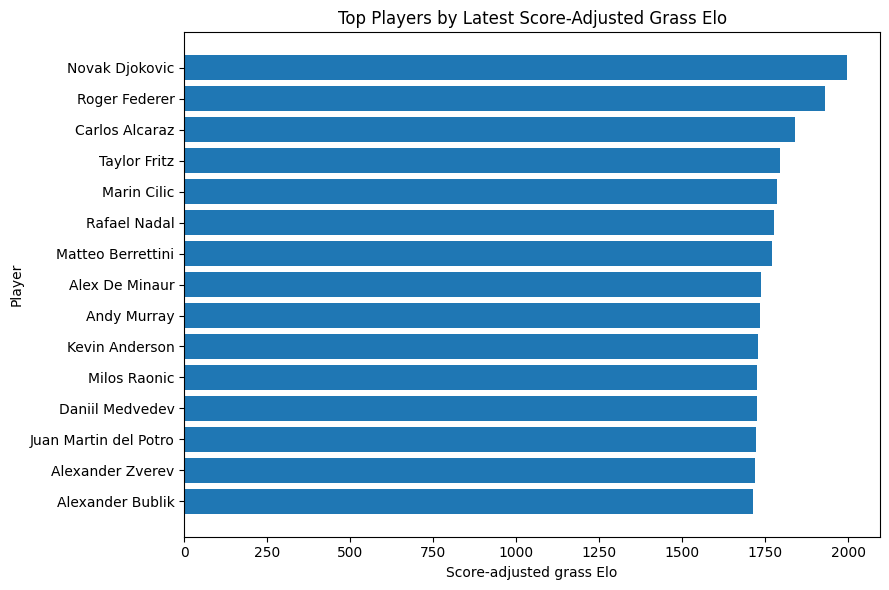

In [250]:
def get_latest_player_ratings(match_df):
    rows = []
    
    for _, row in match_df.iterrows():
        rows.append({
            "date": row["tourney_date"],
            "player_id": row["winner_id"],
            "player_name": row["winner_name"],
            "rank": row["winner_rank"],
            "rank_points": row["winner_rank_points"],
            "surface": row["surface"],
            "elo": row["w_elo_pre"],
            "surface_elo": row["w_surface_elo_pre"],
            "score_elo": row["w_score_elo_pre"],
            "score_surface_elo": row["w_score_surface_elo_pre"]
        })
        
        rows.append({
            "date": row["tourney_date"],
            "player_id": row["loser_id"],
            "player_name": row["loser_name"],
            "rank": row["loser_rank"],
            "rank_points": row["loser_rank_points"],
            "surface": row["surface"],
            "elo": row["l_elo_pre"],
            "surface_elo": row["l_surface_elo_pre"],
            "score_elo": row["l_score_elo_pre"],
            "score_surface_elo": row["l_score_surface_elo_pre"]
        })
    
    ratings_df = pd.DataFrame(rows)
    
    latest_ratings = (
        ratings_df.sort_values("date")
        .groupby("player_id")
        .tail(1)
        .reset_index(drop=True)
    )
    
    return latest_ratings

latest_ratings = get_latest_player_ratings(match_df)

grass_only = match_df[match_df["surface"] == "Grass"].copy()

latest_grass_ratings = get_latest_player_ratings(grass_only)

top_grass_elo = latest_grass_ratings.sort_values(
    "score_surface_elo",
    ascending=False
).head(15)

plt.figure(figsize=(9, 6))
plt.barh(
    top_grass_elo["player_name"][::-1],
    top_grass_elo["score_surface_elo"][::-1]
)
plt.title("Top Players by Latest Score-Adjusted Grass Elo")
plt.xlabel("Score-adjusted grass Elo")
plt.ylabel("Player")
plt.tight_layout()
plt.show()

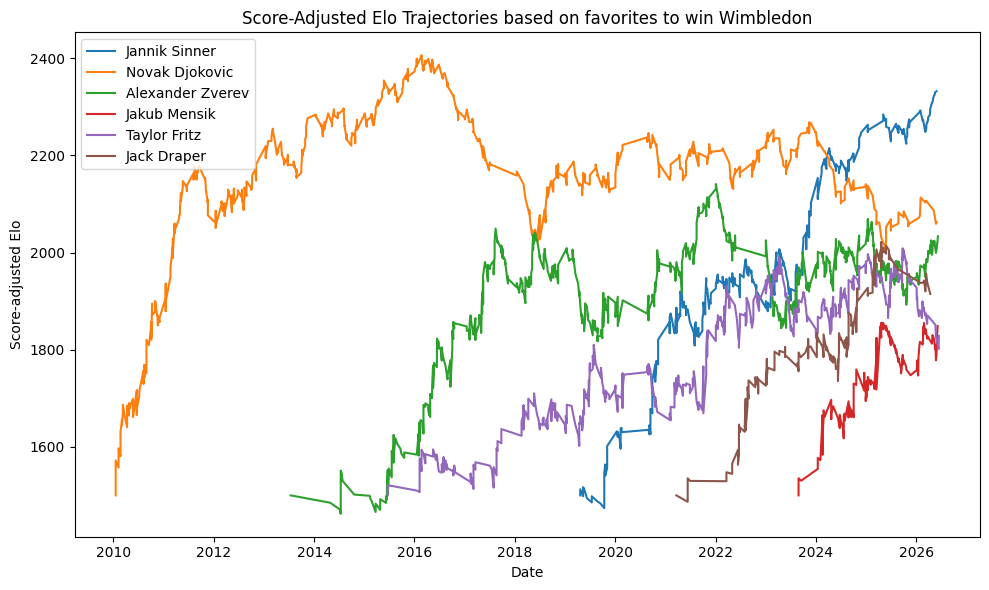

In [278]:
def get_player_elo_history(match_df, player_names):
    rows = []
    
    player_names_lower = [name.lower() for name in player_names]
    
    for _, row in match_df.iterrows():
        winner_name = row["winner_name"]
        loser_name = row["loser_name"]
        
        if str(winner_name).lower() in player_names_lower:
            rows.append({
                "date": row["tourney_date"],
                "player_name": winner_name,
                "elo": row["w_elo_pre"],
                "score_elo": row["w_score_elo_pre"],
                "surface": row["surface"]
            })
        
        if str(loser_name).lower() in player_names_lower:
            rows.append({
                "date": row["tourney_date"],
                "player_name": loser_name,
                "elo": row["l_elo_pre"],
                "score_elo": row["l_score_elo_pre"],
                "surface": row["surface"]
            })
    
    return pd.DataFrame(rows)

players_to_plot = [
    "Jannik Sinner",
    "Novak Djokovic",
    "Alexander Zverev",
    "Jakub Mensik",
    "Taylor Fritz",
    "Jack Draper"
]

elo_history = get_player_elo_history(match_df, players_to_plot)

plt.figure(figsize=(10, 6))

for player in players_to_plot:
    player_df = elo_history[elo_history["player_name"] == player].sort_values("date")
    plt.plot(player_df["date"], player_df["score_elo"], label=player)

plt.title("Score-Adjusted Elo Trajectories based on favorites to win Wimbledon")
plt.xlabel("Date")
plt.ylabel("Score-adjusted Elo")
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\ishan\AppData\Local\Temp\ipykernel_49960\646075287.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calibration_summary = calibration_df.groupby("prob_bin").agg(


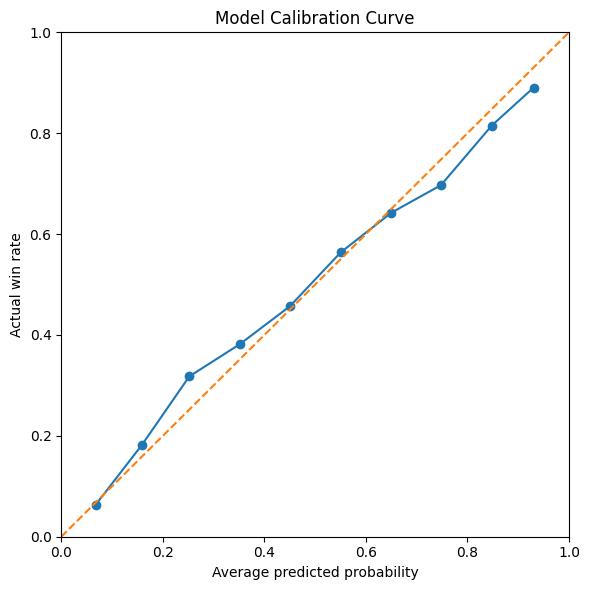

In [252]:
calibration_df = pd.DataFrame({
    "pred_prob": pred_probs,
    "actual": y_test.to_numpy()
})

calibration_df["prob_bin"] = pd.cut(
    calibration_df["pred_prob"],
    bins=np.linspace(0, 1, 11),
    include_lowest=True
)

calibration_summary = calibration_df.groupby("prob_bin").agg(
    avg_pred_prob=("pred_prob", "mean"),
    actual_win_rate=("actual", "mean"),
    matches=("actual", "size")
).reset_index()

calibration_summary

plt.figure(figsize=(6, 6))
plt.plot(
    calibration_summary["avg_pred_prob"],
    calibration_summary["actual_win_rate"],
    marker="o"
)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Model Calibration Curve")
plt.xlabel("Average predicted probability")
plt.ylabel("Actual win rate")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Backtesting

### Wimbledon Match-Level Backtesting

To evaluate the model in a realistic way, I backtest Wimbledon one year at a time. For each Wimbledon, the model is trained only on matches that occurred before that tournament began, then tested on that year's Wimbledon matches. This simulates the information that would have been available before filling out a bracket.

In [30]:
wim_years = [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024, 2025]

def backtest_wimbledon_match_model(neutral_df, feature_cols, years=None, model_name="model"):
    results = []
    all_preds = []
    
    wim_all = neutral_df[
        neutral_df["tourney_name"].str.contains("Wimbledon", case=False, na=False)
    ].copy()
    
    if years is None:
        years = sorted(wim_all["date"].dt.year.unique())
    
    for year in years:
        wim_year = wim_all[wim_all["date"].dt.year == year].copy()
        
        if len(wim_year) == 0:
            continue
        
        cutoff_date = wim_year["date"].min()
        
        train = neutral_df[neutral_df["date"] < cutoff_date].copy()
        test = wim_year.copy()
        
        train = train.dropna(subset=feature_cols + ["A_won"])
        test = test.dropna(subset=feature_cols + ["A_won"])
        
        X_train = train[feature_cols]
        y_train = train["A_won"]
        
        X_test = test[feature_cols]
        y_test = test["A_won"]
        
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("logit", LogisticRegression(max_iter=5000))
        ])
        
        model.fit(X_train, y_train)
        
        pred_probs = model.predict_proba(X_test)[:, 1]
        pred_class = (pred_probs >= 0.5).astype(int)
        
        results.append({
            "model": model_name,
            "year": year,
            "wimbledon_start": cutoff_date,
            "train_matches": len(train),
            "test_matches": len(test),
            "accuracy": accuracy_score(y_test, pred_class),
            "log_loss": log_loss(y_test, pred_probs),
            "brier": brier_score_loss(y_test, pred_probs)
        })
        
        pred_df = test.copy()
        pred_df["model"] = model_name
        pred_df["pred_prob_A_wins"] = pred_probs
        pred_df["pred_class_A_wins"] = pred_class
        pred_df["correct"] = pred_df["pred_class_A_wins"] == pred_df["A_won"]
        pred_df["year"] = year
        
        all_preds.append(pred_df)
    
    results_df = pd.DataFrame(results)
    preds_df = pd.concat(all_preds, ignore_index=True)
    
    return results_df, preds_df


wim_match_results, wim_match_preds = backtest_wimbledon_match_model(
    neutral_df,
    model_feature_cols,
    years=wim_years,
    model_name="full_model"
)

print(wim_match_results)
wim_match_results[["accuracy", "log_loss", "brier"]].mean()

         model  year wimbledon_start  train_matches  test_matches  accuracy  \
0   full_model  2011      2011-06-20           4576           127  0.724409   
1   full_model  2012      2012-06-25           7582           127  0.748031   
2   full_model  2013      2013-06-24          10449           127  0.677165   
3   full_model  2014      2014-06-23          13310           127  0.755906   
4   full_model  2015      2015-06-29          16122           127  0.724409   
5   full_model  2016      2016-06-27          18983           127  0.748031   
6   full_model  2017      2017-07-03          21967           127  0.755906   
7   full_model  2018      2018-07-02          24851           127  0.700787   
8   full_model  2019      2019-07-01          27579           127  0.740157   
9   full_model  2021      2021-06-28          31671           127  0.740157   
10  full_model  2022      2022-06-27          34528           127  0.740157   
11  full_model  2023      2023-07-03          37482 

accuracy    0.730034
log_loss    0.532615
brier       0.178186
dtype: float64

#### Accuracy By Round

In [31]:
round_order = {
    "R128": 1,
    "R64": 2,
    "R32": 3,
    "R16": 4,
    "QF": 5,
    "SF": 6,
    "F": 7
}

wim_round_match_summary = wim_match_preds.groupby("round").agg(
    matches=("correct", "size"),
    accuracy=("correct", "mean")
).reset_index()

wim_round_match_summary["round_order"] = (
    wim_round_match_summary["round"].map(round_order)
)

wim_round_match_summary = wim_round_match_summary.sort_values("round_order")

wim_round_match_summary

,round,matches,accuracy,round_order
2,R128,896,0.712054,1
5,R64,448,0.725446,2
4,R32,224,0.741071,3
3,R16,112,0.785714,4
1,QF,56,0.821429,5
6,SF,28,0.857143,6
0,F,14,0.785714,7


Note: The lower finals accuracy makes sense as there are only 6 Wimbledon Finals matches in the dataset

### Full Bracket-Score Backetesting

#### Define Scoring Rules of Nothing Major Bracket Challenge

In [32]:
round_points = {
    "R128": 10,
    "R64": 20,
    "R32": 40,
    "R16": 80,
    "QF": 160,
    "SF": 320,
    "F": 640
}

round_order = {
    "R128": 1,
    "R64": 2,
    "R32": 3,
    "R16": 4,
    "QF": 5,
    "SF": 6,
    "F": 7
}

ROUND_SEQUENCE = ["R128", "R64", "R32", "R16", "QF", "SF", "F"]

#### Build General GS Bracket Tree

The match data contains each completed match, but it does not directly store a full bracket structure. To score a predicted bracket, I reconstruct the draw tree by linking each match to the previous-round matches that produced its two players. This allows the model to generate internally consistent bracket picks from the first round through the final.

In [33]:
def build_tournament_bracket_tree(match_df, tournament_name, year):
    """
    Reconstructs a 128-player tournament bracket tree for a given tournament and year.

    Parameters:
        match_df: match-level dataframe
        tournament_name: string to match inside tourney_name, e.g. "Wimbledon"
        year: tournament year

    Returns:
        root: final match node
        nodes_by_round: dictionary of nodes for each round
    """
    
    tournament = match_df[
        (match_df["tourney_name"].str.contains(tournament_name, case=False, na=False)) &
        (match_df["tourney_date"].dt.year == year)
    ].copy()
    
    print("Tournament:", tournament_name)
    print("Year:", year)
    print("Matches found:", len(tournament))
    print("Surface:", tournament["surface"].unique())
    print("Round counts:", tournament["round"].value_counts().to_dict())
    
    nodes_by_round = {}
    
    for rnd in ROUND_SEQUENCE:
        round_matches = tournament[tournament["round"] == rnd].copy().reset_index(drop=True)
        nodes = []
        
        for idx, row in round_matches.iterrows():
            node = {
                "round": rnd,
                "round_index": idx,
                "winner_id": row["winner_id"],
                "winner_name": row["winner_name"],
                "loser_id": row["loser_id"],
                "loser_name": row["loser_name"],
                "player_ids": {row["winner_id"], row["loser_id"]},
                "left": None,
                "right": None,
                "row": row
            }
            
            nodes.append(node)
        
        nodes_by_round[rnd] = nodes
    
    # Link each match to the two previous-round matches that produced its players
    for i in range(1, len(ROUND_SEQUENCE)):
        prev_round = ROUND_SEQUENCE[i - 1]
        curr_round = ROUND_SEQUENCE[i]
        
        prev_nodes = nodes_by_round[prev_round]
        curr_nodes = nodes_by_round[curr_round]
        
        for curr_node in curr_nodes:
            feeders = []
            
            for prev_node in prev_nodes:
                if prev_node["winner_id"] in curr_node["player_ids"]:
                    feeders.append(prev_node)
            
            if len(feeders) != 2:
                print(
                    f"WARNING: {year} {tournament_name} {curr_round} match "
                    f"{curr_node['round_index']} has {len(feeders)} feeders instead of 2"
                )
            
            if len(feeders) >= 1:
                curr_node["left"] = feeders[0]
            
            if len(feeders) >= 2:
                curr_node["right"] = feeders[1]
    
    final_nodes = nodes_by_round["F"]
    
    if len(final_nodes) != 1:
        raise ValueError(
            f"Expected exactly one final node for {tournament_name} {year}, "
            f"found {len(final_nodes)}"
        )
    
    return final_nodes[0], nodes_by_round

Quick Sanity Checks

In [120]:
root, nodes_by_round = build_tournament_bracket_tree(
    match_df,
    "Australian Open",
    2025
)

print("\n---------------\n")
rg_root_2026, rg_nodes_2026 = build_tournament_bracket_tree(
    match_df,
    "Roland Garros",
    2025
)
print("\n---------------\n")

root_2024, nodes_2024 = build_tournament_bracket_tree(
    match_df,
    "Wimbledon",
    2025
)
print("\n---------------\n")

root, nodes_by_round = build_tournament_bracket_tree(
    match_df,
    "US Open",
    2025
)

Tournament: Australian Open
Year: 2025
Matches found: 127
Surface: ['Hard']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}

---------------

Tournament: Roland Garros
Year: 2025
Matches found: 127
Surface: ['Clay']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}

---------------

Tournament: Wimbledon
Year: 2025
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}

---------------

Tournament: US Open
Year: 2025
Matches found: 127
Surface: ['Hard']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}


In [34]:
def count_leaf_matches(node):
    if node["round"] == "R128":
        return 1
    
    return count_leaf_matches(node["left"]) + count_leaf_matches(node["right"])

for year in wim_years:
    root, nodes_by_round = build_tournament_bracket_tree(
        match_df,
        "Wimbledon",
        year
    )
    
    print("Year:", year)
    print("Champion:", root["winner_name"])
    print("Finalist:", root["loser_name"])
    print("R128 matches under final tree:", count_leaf_matches(root))
    print("Round counts:", {rnd: len(nodes_by_round[rnd]) for rnd in ROUND_SEQUENCE})
    print("\n------------\n")

Tournament: Wimbledon
Year: 2011
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Year: 2011
Champion: Novak Djokovic
Finalist: Rafael Nadal
R128 matches under final tree: 64
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}

------------

Tournament: Wimbledon
Year: 2012
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Year: 2012
Champion: Roger Federer
Finalist: Andy Murray
R128 matches under final tree: 64
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}

------------

Tournament: Wimbledon
Year: 2013
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Year: 2013
Champion: Andy Murray
Finalist: Novak Djokovic
R128 matches under final tree: 64
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 

#### Generate Projected Bracket From Reconstructed Tree

Pre-Tournament Player Features

In [35]:
def get_tournament_player_features(match_df, tournament_name, year):
    """
    Gets each player's pre-tournament feature profile from their R128 match.

    This is used for bracket simulation because the model needs a fixed
    feature profile for each player before the tournament begins.
    """
    
    tournament = match_df[
        (match_df["tourney_name"].str.contains(tournament_name, case=False, na=False)) &
        (match_df["tourney_date"].dt.year == year)
    ].copy()
    
    r128 = tournament[tournament["round"] == "R128"].copy()
    
    players = {}
    
    for _, row in r128.iterrows():
        players[row["winner_id"]] = {
            "player_id": row["winner_id"],
            "name": row["winner_name"],
            "rank": row["winner_rank"],
            "rank_points": row["winner_rank_points"],
            "elo": row["w_elo_pre"],
            "surface_elo": row["w_surface_elo_pre"],
            "score_elo": row["w_score_elo_pre"],
            "score_surface_elo": row["w_score_surface_elo_pre"],
            "last10_win_pct": row["w_last10_win_pct_pre"],
            "last20_win_pct": row["w_last20_win_pct_pre"],
            "surface_last10_win_pct": row["w_surface_last10_win_pct_pre"],
            "surface_last20_win_pct": row["w_surface_last20_win_pct_pre"],
            "last10_matches": row["w_last10_matches_pre"],
            "last20_matches": row["w_last20_matches_pre"],
            "surface_last10_matches": row["w_surface_last10_matches_pre"],
            "surface_last20_matches": row["w_surface_last20_matches_pre"],
        }
        
        players[row["loser_id"]] = {
            "player_id": row["loser_id"],
            "name": row["loser_name"],
            "rank": row["loser_rank"],
            "rank_points": row["loser_rank_points"],
            "elo": row["l_elo_pre"],
            "surface_elo": row["l_surface_elo_pre"],
            "score_elo": row["l_score_elo_pre"],
            "score_surface_elo": row["l_score_surface_elo_pre"],
            "last10_win_pct": row["l_last10_win_pct_pre"],
            "last20_win_pct": row["l_last20_win_pct_pre"],
            "surface_last10_win_pct": row["l_surface_last10_win_pct_pre"],
            "surface_last20_win_pct": row["l_surface_last20_win_pct_pre"],
            "last10_matches": row["l_last10_matches_pre"],
            "last20_matches": row["l_last20_matches_pre"],
            "surface_last10_matches": row["l_surface_last10_matches_pre"],
            "surface_last20_matches": row["l_surface_last20_matches_pre"],
        }
    
    return players

Train Model On Pre-Tournament Matches

In [36]:
def train_model_before_tournament(neutral_df, tournament_name, year, feature_cols):
    """
    Trains the match prediction model using only matches before
    the selected tournament began.

    Missing feature values are imputed using training-set medians.
    """
    
    tournament = neutral_df[
        (neutral_df["tourney_name"].str.contains(tournament_name, case=False, na=False)) &
        (neutral_df["date"].dt.year == year)
    ].copy()
    
    if len(tournament) == 0:
        raise ValueError(f"No matches found for {tournament_name} {year}")
    
    cutoff_date = tournament["date"].min()
    
    train = neutral_df[
        neutral_df["date"] < cutoff_date
    ].dropna(subset=["A_won"]).copy()
    
    X_train = train[feature_cols]
    y_train = train["A_won"]
    
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(max_iter=5000))
    ])
    
    model.fit(X_train, y_train)
    
    print("Tournament:", tournament_name, year)
    print("Training cutoff:", cutoff_date)
    print("Training matches:", len(train))
    
    return model

Matchup Feature Function -> Converts two hypothetical players into the exact feature row the model expects

In [37]:
def make_matchup_features(player_A, player_B, feature_cols):
    """
    Creates a one-row dataframe of model features for Player A vs Player B.
    """
    
    row = {
        "elo_diff": player_A["elo"] - player_B["elo"],
        "surface_elo_diff": player_A["surface_elo"] - player_B["surface_elo"],
        "score_elo_diff": player_A["score_elo"] - player_B["score_elo"],
        "score_surface_elo_diff": player_A["score_surface_elo"] - player_B["score_surface_elo"],
        
        "rank_diff": player_B["rank"] - player_A["rank"],
        
        "log_rank_points_diff": (
            np.log1p(player_A["rank_points"]) 
            - np.log1p(player_B["rank_points"])
        ),
        
        "last10_win_pct_pre_diff": (
            player_A["last10_win_pct"] - player_B["last10_win_pct"]
        ),
        
        "last20_win_pct_pre_diff": (
            player_A["last20_win_pct"] - player_B["last20_win_pct"]
        ),
        
        "surface_last10_win_pct_pre_diff": (
            player_A["surface_last10_win_pct"] - player_B["surface_last10_win_pct"]
        ),
        
        "surface_last20_win_pct_pre_diff": (
            player_A["surface_last20_win_pct"] - player_B["surface_last20_win_pct"]
        ),
        
        "last10_matches_pre_diff": (
            player_A["last10_matches"] - player_B["last10_matches"]
        ),
        
        "last20_matches_pre_diff": (
            player_A["last20_matches"] - player_B["last20_matches"]
        ),
        
        "surface_last10_matches_pre_diff": (
            player_A["surface_last10_matches"] - player_B["surface_last10_matches"]
        ),
        
        "surface_last20_matches_pre_diff": (
            player_A["surface_last20_matches"] - player_B["surface_last20_matches"]
        )
    }
    
    return pd.DataFrame([row])[feature_cols]

Matchup Prediction Function

In [38]:
def predict_player_A_win_prob(model, player_A, player_B, feature_cols):
    """
    Predicts the probability that Player A beats Player B.
    """
    
    X = make_matchup_features(player_A, player_B, feature_cols)
    
    return model.predict_proba(X)[:, 1][0]

#### Favorite Pick Bracket Generator

In [39]:
def generate_favorite_bracket_from_tree(node, players, model, feature_cols, picks=None):
    """
    Recursively generates a bracket by picking the model favorite
    in each projected matchup.
    """
    
    if picks is None:
        picks = []
    
    # Base case: actual first-round matchup
    if node["round"] == "R128":
        p1 = players[node["winner_id"]]
        p2 = players[node["loser_id"]]
    
    # Recursive case: predict winners from the two feeder branches first
    else:
        p1, picks = generate_favorite_bracket_from_tree(
            node["left"],
            players,
            model,
            feature_cols,
            picks
        )
        
        p2, picks = generate_favorite_bracket_from_tree(
            node["right"],
            players,
            model,
            feature_cols,
            picks
        )
    
    p1_win_prob = predict_player_A_win_prob(
        model,
        p1,
        p2,
        feature_cols
    )
    
    if p1_win_prob >= 0.5:
        pick = p1
        pick_prob = p1_win_prob
    else:
        pick = p2
        pick_prob = 1 - p1_win_prob
    
    picks.append({
        "round": node["round"],
        "round_index": node["round_index"],
        "player_1": p1["name"],
        "player_2": p2["name"],
        "pick_id": pick["player_id"],
        "pick_name": pick["name"],
        "pick_prob": pick_prob,
        "actual_winner_id": node["winner_id"],
        "actual_winner_name": node["winner_name"]
    })
    
    return pick, picks

Test on Wimbledon 2024

In [127]:
root_2024, nodes_2024 = build_tournament_bracket_tree(
    match_df,
    "Wimbledon",
    2024
)

players_2024 = get_tournament_player_features(
    match_df,
    "Wimbledon",
    2024
)

model_2024 = train_model_before_tournament(
    neutral_df,
    "Wimbledon",
    2024,
    model_feature_cols
)

champion_pick_2024, picks_2024 = generate_favorite_bracket_from_tree(
    root_2024,
    players_2024,
    model_2024,
    model_feature_cols
)

print("Predicted champion:", champion_pick_2024["name"])

Tournament: Wimbledon
Year: 2024
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Wimbledon 2024
Training cutoff: 2024-07-01 00:00:00
Training matches: 17563
Predicted champion: Novak Djokovic


In [128]:
picks_2024_df = pd.DataFrame(picks_2024)

picks_2024_df.head()

,round,round_index,player_1,player_2,pick_id,pick_name,pick_prob,actual_winner_id,actual_winner_name
0,R128,26,Tallon Griekspoor,Daniel Elahi Galan,GJ37,Tallon Griekspoor,0.702801,GJ37,Tallon Griekspoor
1,R128,30,Miomir Kecmanovic,Sumit Nagal,KI95,Miomir Kecmanovic,0.675770,KI95,Miomir Kecmanovic
2,R64,9,Tallon Griekspoor,Miomir Kecmanovic,GJ37,Tallon Griekspoor,0.555816,KI95,Miomir Kecmanovic
3,R128,10,Matteo Berrettini,Marton Fucsovics,BK40,Matteo Berrettini,0.629187,BK40,Matteo Berrettini
4,R128,27,Jannik Sinner,Yannick Hanfmann,S0AG,Jannik Sinner,0.913601,S0AG,Jannik Sinner


In [129]:
picks_2024_df["correct"] = (
    picks_2024_df["pick_id"] == picks_2024_df["actual_winner_id"]
)

picks_2024_df["points_possible"] = (
    picks_2024_df["round"].map(round_points)
)

picks_2024_df["points_earned"] = np.where(
    picks_2024_df["correct"],
    picks_2024_df["points_possible"],
    0
)

In [130]:
picks_2024_df.groupby("round").agg(
    correct=("correct", "sum"),
    total=("correct", "size"),
    accuracy=("correct", "mean"),
    points=("points_earned", "sum"),
    possible=("points_possible", "sum")
).reset_index()

print("Score:", picks_2024_df["points_earned"].sum())
print("Possible:", picks_2024_df["points_possible"].sum())
print("Score %:", picks_2024_df["points_earned"].sum() / picks_2024_df["points_possible"].sum())
print("Pick accuracy:", picks_2024_df["correct"].mean())
print("Predicted champion:", picks_2024_df.loc[picks_2024_df["round"] == "F", "pick_name"].iloc[0])
print("Actual champion:", picks_2024_df.loc[picks_2024_df["round"] == "F", "actual_winner_name"].iloc[0])

Score: 2430
Possible: 4480
Score %: 0.5424107142857143
Pick accuracy: 0.6929133858267716
Predicted champion: Novak Djokovic
Actual champion: Carlos Alcaraz


### Favorite Pick Bracket Backtest

Function for scoring one favorite pick tournament bracket

In [40]:
def generate_and_score_favorite_tournament_bracket(
    match_df,
    neutral_df,
    tournament_name,
    year,
    feature_cols,
    round_points
):
    """
    Generates and scores a favorite-pick bracket for one tournament.
    """
    
    root, nodes_by_round = build_tournament_bracket_tree(
        match_df,
        tournament_name,
        year
    )
    
    players = get_tournament_player_features(
        match_df,
        tournament_name,
        year
    )
    
    model = train_model_before_tournament(
        neutral_df,
        tournament_name,
        year,
        feature_cols
    )
    
    champion_pick, picks = generate_favorite_bracket_from_tree(
        root,
        players,
        model,
        feature_cols
    )
    
    picks_df = pd.DataFrame(picks)
    picks_df["year"] = year
    picks_df["tournament"] = tournament_name
    
    picks_df["correct"] = (
        picks_df["pick_id"] == picks_df["actual_winner_id"]
    )
    
    picks_df["points_possible"] = picks_df["round"].map(round_points)
    
    picks_df["points_earned"] = np.where(
        picks_df["correct"],
        picks_df["points_possible"],
        0
    )
    
    return picks_df

Backtest favorite pick brackets across years

In [41]:
def backtest_favorite_bracket_scores(
    match_df,
    neutral_df,
    tournament_name,
    years,
    feature_cols,
    round_points
):
    """
    Backtests favorite-pick bracket scores across multiple tournament years.
    """
    
    all_year_summaries = []
    all_scored_brackets = []
    
    for year in years:
        print(f"Running {tournament_name} {year}...")
        
        scored = generate_and_score_favorite_tournament_bracket(
            match_df,
            neutral_df,
            tournament_name,
            year,
            feature_cols,
            round_points
        )
        
        champion_row = scored[scored["round"] == "F"].iloc[0]
        
        summary = {
            "year": year,
            "tournament": tournament_name,
            "score": scored["points_earned"].sum(),
            "possible": scored["points_possible"].sum(),
            "score_pct": scored["points_earned"].sum() / scored["points_possible"].sum(),
            "correct_picks": scored["correct"].sum(),
            "total_picks": len(scored),
            "pick_accuracy": scored["correct"].mean(),
            "predicted_champion": champion_row["pick_name"],
            "actual_champion": champion_row["actual_winner_name"],
            "champion_correct": champion_row["correct"]
        }
        
        all_year_summaries.append(summary)
        all_scored_brackets.append(scored)
    
    results_df = pd.DataFrame(all_year_summaries)
    scored_brackets_df = pd.concat(all_scored_brackets, ignore_index=True)
    
    return results_df, scored_brackets_df

Run favorite pick backtest on all available GS Data

In [162]:
wim_years = wim_years

favorite_bracket_results, favorite_scored_brackets = backtest_favorite_bracket_scores(
    match_df,
    neutral_df,
    "Wimbledon",
    wim_years,
    model_feature_cols,
    round_points
)

favorite_bracket_results

Running Wimbledon 2019...
Tournament: Wimbledon
Year: 2019
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Wimbledon 2019
Training cutoff: 2019-07-01 00:00:00
Training matches: 4484
Running Wimbledon 2021...
Tournament: Wimbledon
Year: 2021
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Wimbledon 2021
Training cutoff: 2021-06-28 00:00:00
Training matches: 8654
Running Wimbledon 2022...
Tournament: Wimbledon
Year: 2022
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Wimbledon 2022
Training cutoff: 2022-06-27 00:00:00
Training matches: 11542
Running Wimbledon 2023...
Tournament: Wimbledon
Year: 2023
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament

,year,tournament,score,possible,score_pct,correct_picks,total_picks,pick_accuracy,predicted_champion,actual_champion,champion_correct
0,2019,Wimbledon,2850,4480,0.636161,81,127,0.637795,Novak Djokovic,Novak Djokovic,True
1,2021,Wimbledon,2800,4480,0.625000,83,127,0.653543,Novak Djokovic,Novak Djokovic,True
2,2022,Wimbledon,2590,4480,0.578125,81,127,0.637795,Novak Djokovic,Novak Djokovic,True
3,2023,Wimbledon,2620,4480,0.584821,78,127,0.614173,Novak Djokovic,Carlos Alcaraz,False
4,2024,Wimbledon,2430,4480,0.542411,88,127,0.692913,Novak Djokovic,Carlos Alcaraz,False
5,2025,Wimbledon,2360,4480,0.526786,67,127,0.527559,Carlos Alcaraz,Jannik Sinner,False


In [163]:
favorite_round_summary = favorite_scored_brackets.groupby("round").agg(
    correct=("correct", "sum"),
    total=("correct", "size"),
    accuracy=("correct", "mean"),
    points=("points_earned", "sum"),
    possible=("points_possible", "sum")
).reset_index()

favorite_round_summary["score_pct"] = (
    favorite_round_summary["points"] / favorite_round_summary["possible"]
)

favorite_round_summary["round_order"] = (
    favorite_round_summary["round"].map(round_order)
)

favorite_round_summary = favorite_round_summary.sort_values("round_order")

favorite_round_summary

,round,correct,total,accuracy,points,possible,score_pct,round_order
2,R128,271,384,0.705729,2710,3840,0.705729,1
5,R64,107,192,0.557292,2140,3840,0.557292,2
4,R32,50,96,0.520833,2000,3840,0.520833,3
3,R16,24,48,0.500000,1920,3840,0.500000,4
1,QF,15,24,0.625000,2400,3840,0.625000,5
6,SF,8,12,0.666667,2560,3840,0.666667,6
0,F,3,6,0.500000,1920,3840,0.500000,7


In [42]:
french_years = [2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]

favorite_bracket_results, favorite_scored_brackets = backtest_favorite_bracket_scores(
    match_df,
    neutral_df,
    "Roland Garros",
    french_years,
    model_feature_cols,
    round_points
)

favorite_bracket_results

Running Roland Garros 2019...
Tournament: Roland Garros
Year: 2019
Matches found: 127
Surface: ['Clay']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Roland Garros 2019
Training cutoff: 2019-05-27 00:00:00
Training matches: 27937
Running Roland Garros 2020...
Tournament: Roland Garros
Year: 2020
Matches found: 127
Surface: ['Clay']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Roland Garros 2020
Training cutoff: 2020-09-28 00:00:00
Training matches: 30527
Running Roland Garros 2021...
Tournament: Roland Garros
Year: 2021
Matches found: 127
Surface: ['Clay']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Roland Garros 2021
Training cutoff: 2021-05-31 00:00:00
Training matches: 32133
Running Roland Garros 2022...
Tournament: Roland Garros
Year: 2022
Matches found: 127
Surface: ['Clay']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16

,year,tournament,score,possible,score_pct,correct_picks,total_picks,pick_accuracy,predicted_champion,actual_champion,champion_correct
0,2019,Roland Garros,3470,4480,0.774554,96,127,0.755906,Rafael Nadal,Rafael Nadal,True
1,2020,Roland Garros,3280,4480,0.732143,77,127,0.606299,Rafael Nadal,Rafael Nadal,True
2,2021,Roland Garros,2500,4480,0.558036,79,127,0.622047,Rafael Nadal,Novak Djokovic,False
3,2022,Roland Garros,2890,4480,0.645089,83,127,0.653543,Rafael Nadal,Rafael Nadal,True
4,2023,Roland Garros,2790,4480,0.622768,79,127,0.622047,Novak Djokovic,Novak Djokovic,True
5,2024,Roland Garros,2430,4480,0.542411,91,127,0.716535,Novak Djokovic,Carlos Alcaraz,False
6,2025,Roland Garros,3410,4480,0.761161,81,127,0.637795,Carlos Alcaraz,Carlos Alcaraz,True
7,2026,Roland Garros,1240,4480,0.276786,65,127,0.511811,Jannik Sinner,Alexander Zverev,False


In [165]:
us_years = [2019, 2020, 2021, 2022, 2023, 2024, 2025]

favorite_bracket_results, favorite_scored_brackets = backtest_favorite_bracket_scores(
    match_df,
    neutral_df,
    "US Open",
    us_years,
    model_feature_cols,
    round_points
)

favorite_bracket_results

Running US Open 2019...
Tournament: US Open
Year: 2019
Matches found: 127
Surface: ['Hard']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: US Open 2019
Training cutoff: 2019-08-26 00:00:00
Training matches: 5035
Running US Open 2020...
Tournament: US Open
Year: 2020
Matches found: 127
Surface: ['Hard']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: US Open 2020
Training cutoff: 2020-08-31 00:00:00
Training matches: 6538
Running US Open 2021...
Tournament: US Open
Year: 2021
Matches found: 127
Surface: ['Hard']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: US Open 2021
Training cutoff: 2021-08-30 00:00:00
Training matches: 9257
Running US Open 2022...
Tournament: US Open
Year: 2022
Matches found: 127
Surface: ['Hard']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: US Open 2022
Training cut

,year,tournament,score,possible,score_pct,correct_picks,total_picks,pick_accuracy,predicted_champion,actual_champion,champion_correct
0,2019,US Open,2390,4480,0.533482,69,127,0.543307,Rafael Nadal,Rafael Nadal,True
1,2020,US Open,1800,4480,0.401786,77,127,0.606299,Novak Djokovic,Dominic Thiem,False
2,2021,US Open,2420,4480,0.540179,72,127,0.566929,Novak Djokovic,Daniil Medvedev,False
3,2022,US Open,1570,4480,0.350446,77,127,0.606299,Rafael Nadal,Carlos Alcaraz,False
4,2023,US Open,2890,4480,0.645089,75,127,0.590551,Novak Djokovic,Novak Djokovic,True
5,2024,US Open,2790,4480,0.622768,81,127,0.637795,Jannik Sinner,Jannik Sinner,True
6,2025,US Open,2590,4480,0.578125,77,127,0.606299,Jannik Sinner,Carlos Alcaraz,False


In [166]:
aus_years = french_years

favorite_bracket_results, favorite_scored_brackets = backtest_favorite_bracket_scores(
    match_df,
    neutral_df,
    "Australian Open",
    aus_years,
    model_feature_cols,
    round_points
)

favorite_bracket_results

Running Australian Open 2019...
Tournament: Australian Open
Year: 2019
Matches found: 127
Surface: ['Hard']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Australian Open 2019
Training cutoff: 2019-01-14 00:00:00
Training matches: 3065
Running Australian Open 2020...
Tournament: Australian Open
Year: 2020
Matches found: 127
Surface: ['Hard']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Australian Open 2020
Training cutoff: 2020-01-20 00:00:00
Training matches: 5899
Running Australian Open 2021...
Tournament: Australian Open
Year: 2021
Matches found: 127
Surface: ['Hard']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Australian Open 2021
Training cutoff: 2021-02-08 00:00:00
Training matches: 7396
Running Australian Open 2022...
Tournament: Australian Open
Year: 2022
Matches found: 127
Surface: ['Hard']
Round counts: {'R128': 64, 'R64': 

,year,tournament,score,possible,score_pct,correct_picks,total_picks,pick_accuracy,predicted_champion,actual_champion,champion_correct
0,2019,Australian Open,3140,4480,0.700893,86,127,0.677165,Novak Djokovic,Novak Djokovic,True
1,2020,Australian Open,2900,4480,0.647321,87,127,0.685039,Novak Djokovic,Novak Djokovic,True
2,2021,Australian Open,2330,4480,0.520089,83,127,0.653543,Rafael Nadal,Novak Djokovic,False
3,2022,Australian Open,2630,4480,0.587054,93,127,0.732283,Daniil Medvedev,Rafael Nadal,False
4,2023,Australian Open,2570,4480,0.573661,77,127,0.606299,Novak Djokovic,Novak Djokovic,True
5,2024,Australian Open,2670,4480,0.595982,88,127,0.692913,Novak Djokovic,Jannik Sinner,False
6,2025,Australian Open,3140,4480,0.700893,85,127,0.669291,Jannik Sinner,Jannik Sinner,True
7,2026,Australian Open,2490,4480,0.555804,82,127,0.645669,Jannik Sinner,Carlos Alcaraz,False


## Expected-Score Optimized Bracket

The favorite-pick bracket asks: who is more likeyl to win this projected match?

The opimized bracket asks: Which internally consistent bracket maximizes expected points?

### Cached matchup probability function

In [43]:
def get_match_win_prob_cached(model, player_A, player_B, feature_cols, prob_cache):
    """
    Returns P(Player A beats Player B), using a cache so repeated
    matchup probabilities do not need to be recalculated.
    """
    
    A_id = player_A["player_id"]
    B_id = player_B["player_id"]
    
    key = (A_id, B_id)
    
    if key not in prob_cache:
        p_A_wins = predict_player_A_win_prob(
            model,
            player_A,
            player_B,
            feature_cols
        )
        
        prob_cache[(A_id, B_id)] = p_A_wins
        prob_cache[(B_id, A_id)] = 1 - p_A_wins
    
    return prob_cache[key]

### Expected Score Optimizer

In [44]:
def solve_expected_score_bracket(node, players, model, feature_cols, round_points, prob_cache=None):
    """
    Solves for the bracket picks that maximize expected bracket score.

    Returns:
        node_win_probs:
            Dictionary mapping player_id to probability of winning this section.

        best_by_winner:
            Dictionary mapping picked winner_id to the best bracket subtree
            if that player is picked to win this section.
    """
    
    if prob_cache is None:
        prob_cache = {}
    
    current_round = node["round"]
    current_points = round_points[current_round]
    
    # Base case: first-round match
    if current_round == "R128":
        p1 = players[node["winner_id"]]
        p2 = players[node["loser_id"]]
        
        p1_win_prob = get_match_win_prob_cached(
            model,
            p1,
            p2,
            feature_cols,
            prob_cache
        )
        
        node_win_probs = {
            p1["player_id"]: p1_win_prob,
            p2["player_id"]: 1 - p1_win_prob
        }
        
        best_by_winner = {}
        
        for p in [p1, p2]:
            pid = p["player_id"]
            win_prob = node_win_probs[pid]
            expected_points = current_points * win_prob
            
            pick = {
                "round": current_round,
                "round_index": node["round_index"],
                "player_1": p1["name"],
                "player_2": p2["name"],
                "pick_id": pid,
                "pick_name": p["name"],
                "win_prob": win_prob,
                "expected_points": expected_points,
                "actual_winner_id": node["winner_id"],
                "actual_winner_name": node["winner_name"]
            }
            
            best_by_winner[pid] = {
                "player": p,
                "expected_score": expected_points,
                "picks": [pick]
            }
        
        return node_win_probs, best_by_winner
    
    # Recursive case: solve both halves first
    left_probs, left_best = solve_expected_score_bracket(
        node["left"],
        players,
        model,
        feature_cols,
        round_points,
        prob_cache
    )
    
    right_probs, right_best = solve_expected_score_bracket(
        node["right"],
        players,
        model,
        feature_cols,
        round_points,
        prob_cache
    )
    
    # Probability each player wins this section
    node_win_probs = {}
    
    for left_id, p_left_reaches in left_probs.items():
        left_player = players[left_id]
        
        prob_wins_node_given_reaches = 0
        
        for right_id, p_right_reaches in right_probs.items():
            right_player = players[right_id]
            
            p_left_beats_right = get_match_win_prob_cached(
                model,
                left_player,
                right_player,
                feature_cols,
                prob_cache
            )
            
            prob_wins_node_given_reaches += p_right_reaches * p_left_beats_right
        
        node_win_probs[left_id] = p_left_reaches * prob_wins_node_given_reaches
    
    for right_id, p_right_reaches in right_probs.items():
        right_player = players[right_id]
        
        prob_wins_node_given_reaches = 0
        
        for left_id, p_left_reaches in left_probs.items():
            left_player = players[left_id]
            
            p_right_beats_left = get_match_win_prob_cached(
                model,
                right_player,
                left_player,
                feature_cols,
                prob_cache
            )
            
            prob_wins_node_given_reaches += p_left_reaches * p_right_beats_left
        
        node_win_probs[right_id] = p_right_reaches * prob_wins_node_given_reaches
    
    # Best bracket from each side, regardless of who wins that side
    best_left_overall = max(
        left_best.values(),
        key=lambda x: x["expected_score"]
    )
    
    best_right_overall = max(
        right_best.values(),
        key=lambda x: x["expected_score"]
    )
    
    best_by_winner = {}
    
    # If a left-side player is picked to win this section
    for left_id, left_option in left_best.items():
        picked_player = left_option["player"]
        opponent_pick = best_right_overall["player"]
        
        win_prob = node_win_probs[left_id]
        expected_points = current_points * win_prob
        
        current_pick = {
            "round": current_round,
            "round_index": node["round_index"],
            "player_1": picked_player["name"],
            "player_2": opponent_pick["name"],
            "pick_id": left_id,
            "pick_name": picked_player["name"],
            "win_prob": win_prob,
            "expected_points": expected_points,
            "actual_winner_id": node["winner_id"],
            "actual_winner_name": node["winner_name"]
        }
        
        total_expected_score = (
            left_option["expected_score"]
            + best_right_overall["expected_score"]
            + expected_points
        )
        
        best_by_winner[left_id] = {
            "player": picked_player,
            "expected_score": total_expected_score,
            "picks": left_option["picks"] + best_right_overall["picks"] + [current_pick]
        }
    
    # If a right-side player is picked to win this section
    for right_id, right_option in right_best.items():
        picked_player = right_option["player"]
        opponent_pick = best_left_overall["player"]
        
        win_prob = node_win_probs[right_id]
        expected_points = current_points * win_prob
        
        current_pick = {
            "round": current_round,
            "round_index": node["round_index"],
            "player_1": opponent_pick["name"],
            "player_2": picked_player["name"],
            "pick_id": right_id,
            "pick_name": picked_player["name"],
            "win_prob": win_prob,
            "expected_points": expected_points,
            "actual_winner_id": node["winner_id"],
            "actual_winner_name": node["winner_name"]
        }
        
        total_expected_score = (
            best_left_overall["expected_score"]
            + right_option["expected_score"]
            + expected_points
        )
        
        best_by_winner[right_id] = {
            "player": picked_player,
            "expected_score": total_expected_score,
            "picks": best_left_overall["picks"] + right_option["picks"] + [current_pick]
        }
    
    return node_win_probs, best_by_winner

### Generate and score one optimized tournament bracket

In [45]:
def generate_and_score_optimized_tournament_bracket(
    match_df,
    neutral_df,
    tournament_name,
    year,
    feature_cols,
    round_points
):
    """
    Generates and scores an expected-score optimized bracket for one tournament.
    """
    
    root, nodes_by_round = build_tournament_bracket_tree(
        match_df,
        tournament_name,
        year
    )
    
    players = get_tournament_player_features(
        match_df,
        tournament_name,
        year
    )
    
    model = train_model_before_tournament(
        neutral_df,
        tournament_name,
        year,
        feature_cols
    )
    
    root_win_probs, best_by_champion = solve_expected_score_bracket(
        root,
        players,
        model,
        feature_cols,
        round_points
    )
    
    best_champion_option = max(
        best_by_champion.values(),
        key=lambda x: x["expected_score"]
    )
    
    picks_df = pd.DataFrame(best_champion_option["picks"])
    picks_df["year"] = year
    picks_df["tournament"] = tournament_name
    picks_df["optimized_expected_score"] = best_champion_option["expected_score"]
    
    picks_df["correct"] = (
        picks_df["pick_id"] == picks_df["actual_winner_id"]
    )
    
    picks_df["points_possible"] = picks_df["round"].map(round_points)
    
    picks_df["points_earned"] = np.where(
        picks_df["correct"],
        picks_df["points_possible"],
        0
    )
    
    return picks_df, root_win_probs, best_champion_option

### Backtest optimized bracket across years

In [46]:
def backtest_optimized_bracket_scores(
    match_df,
    neutral_df,
    tournament_name,
    years,
    feature_cols,
    round_points
):
    """
    Backtests expected-score optimized brackets across multiple tournament years.
    """
    
    all_year_summaries = []
    all_scored_brackets = []
    all_champ_probs = []
    
    for year in years:
        print(f"Running {tournament_name} {year}...")
        
        scored, root_win_probs, best_champion_option = generate_and_score_optimized_tournament_bracket(
            match_df,
            neutral_df,
            tournament_name,
            year,
            feature_cols,
            round_points
        )
        
        champion_row = scored[scored["round"] == "F"].iloc[0]
        
        summary = {
            "year": year,
            "tournament": tournament_name,
            "score": scored["points_earned"].sum(),
            "possible": scored["points_possible"].sum(),
            "score_pct": scored["points_earned"].sum() / scored["points_possible"].sum(),
            "correct_picks": scored["correct"].sum(),
            "total_picks": len(scored),
            "pick_accuracy": scored["correct"].mean(),
            "predicted_champion": champion_row["pick_name"],
            "actual_champion": champion_row["actual_winner_name"],
            "champion_correct": champion_row["correct"],
            "optimized_expected_score": best_champion_option["expected_score"]
        }
        
        all_year_summaries.append(summary)
        all_scored_brackets.append(scored)
        
        players = get_tournament_player_features(
            match_df,
            tournament_name,
            year
        )
        
        champ_probs_year = pd.DataFrame([
            {
                "year": year,
                "tournament": tournament_name,
                "player_id": pid,
                "player_name": players[pid]["name"],
                "championship_prob": prob
            }
            for pid, prob in root_win_probs.items()
        ])
        
        all_champ_probs.append(champ_probs_year)
    
    results_df = pd.DataFrame(all_year_summaries)
    scored_brackets_df = pd.concat(all_scored_brackets, ignore_index=True)
    champ_probs_df = pd.concat(all_champ_probs, ignore_index=True)
    
    return results_df, scored_brackets_df, champ_probs_df

### Run Optimized Wimbledon Backtest

In [171]:
optimized_bracket_results, optimized_scored_brackets, optimized_champ_probs = backtest_optimized_bracket_scores(
    match_df,
    neutral_df,
    "Wimbledon",
    wim_years,
    model_feature_cols,
    round_points
)

optimized_bracket_results

Running Wimbledon 2019...
Tournament: Wimbledon
Year: 2019
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Wimbledon 2019
Training cutoff: 2019-07-01 00:00:00
Training matches: 4484
Running Wimbledon 2021...
Tournament: Wimbledon
Year: 2021
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Wimbledon 2021
Training cutoff: 2021-06-28 00:00:00
Training matches: 8654
Running Wimbledon 2022...
Tournament: Wimbledon
Year: 2022
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Wimbledon 2022
Training cutoff: 2022-06-27 00:00:00
Training matches: 11542
Running Wimbledon 2023...
Tournament: Wimbledon
Year: 2023
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament

,year,tournament,score,possible,score_pct,correct_picks,total_picks,pick_accuracy,predicted_champion,actual_champion,champion_correct,optimized_expected_score
0,2019,Wimbledon,3210,4480,0.716518,83,127,0.653543,Novak Djokovic,Novak Djokovic,True,2162.160646
1,2021,Wimbledon,2840,4480,0.633929,84,127,0.661417,Novak Djokovic,Novak Djokovic,True,2067.287443
2,2022,Wimbledon,2630,4480,0.587054,82,127,0.645669,Novak Djokovic,Novak Djokovic,True,2113.266434
3,2023,Wimbledon,2600,4480,0.580357,77,127,0.606299,Novak Djokovic,Carlos Alcaraz,False,2065.101627
4,2024,Wimbledon,2430,4480,0.542411,88,127,0.692913,Novak Djokovic,Carlos Alcaraz,False,2075.950484
5,2025,Wimbledon,2360,4480,0.526786,67,127,0.527559,Carlos Alcaraz,Jannik Sinner,False,2074.800533


In [174]:
WIMBLEDON_YEARS = [2019, 2021, 2022, 2023, 2024, 2025]

wim_favorite_results, wim_favorite_scored = backtest_favorite_bracket_scores(
    match_df,
    neutral_df,
    "Wimbledon",
    WIMBLEDON_YEARS,
    model_feature_cols,
    round_points
)

wim_optimized_results, wim_optimized_scored, wim_optimized_champ_probs = backtest_optimized_bracket_scores(
    match_df,
    neutral_df,
    "Wimbledon",
    WIMBLEDON_YEARS,
    model_feature_cols,
    round_points
)

Running Wimbledon 2019...
Tournament: Wimbledon
Year: 2019
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Wimbledon 2019
Training cutoff: 2019-07-01 00:00:00
Training matches: 4484
Running Wimbledon 2021...
Tournament: Wimbledon
Year: 2021
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Wimbledon 2021
Training cutoff: 2021-06-28 00:00:00
Training matches: 8654
Running Wimbledon 2022...
Tournament: Wimbledon
Year: 2022
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Wimbledon 2022
Training cutoff: 2022-06-27 00:00:00
Training matches: 11542
Running Wimbledon 2023...
Tournament: Wimbledon
Year: 2023
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament

Comparing Optimized model to Favorites Picker

In [175]:
wim_favorite_compare = wim_favorite_results.copy()
wim_favorite_compare["model"] = "favorite_pick"

wim_optimized_compare = wim_optimized_results.copy()
wim_optimized_compare["model"] = "expected_score_optimized"

wim_bracket_comparison = pd.concat([
    wim_favorite_compare,
    wim_optimized_compare
], ignore_index=True)

wim_bracket_comparison.groupby("model").agg(
    avg_score=("score", "mean"),
    avg_score_pct=("score_pct", "mean"),
    avg_pick_accuracy=("pick_accuracy", "mean"),
    champion_accuracy=("champion_correct", "mean")
).reset_index()

,model,avg_score,avg_score_pct,avg_pick_accuracy,champion_accuracy
0,expected_score_optimized,2678.333333,0.597842,0.631234,0.5
1,favorite_pick,2608.333333,0.582217,0.627297,0.5


In [176]:
wim_optimized_vs_favorite = wim_favorite_scored.merge(
    wim_optimized_scored,
    on=["year", "tournament", "round", "round_index"],
    suffixes=("_favorite", "_optimized")
)

wim_optimized_changed_picks = wim_optimized_vs_favorite[
    wim_optimized_vs_favorite["pick_id_favorite"] 
    != wim_optimized_vs_favorite["pick_id_optimized"]
].copy()

wim_optimized_changed_summary = wim_optimized_changed_picks.groupby("round").agg(
    changed_picks=("round", "size"),
    favorite_correct=("correct_favorite", "sum"),
    optimized_correct=("correct_optimized", "sum"),
    favorite_points=("points_earned_favorite", "sum"),
    optimized_points=("points_earned_optimized", "sum")
).reset_index()

wim_optimized_changed_summary["point_difference"] = (
    wim_optimized_changed_summary["optimized_points"]
    - wim_optimized_changed_summary["favorite_points"]
)

wim_optimized_changed_summary["round_order"] = (
    wim_optimized_changed_summary["round"].map(round_order)
)

wim_optimized_changed_summary = (
    wim_optimized_changed_summary.sort_values("round_order")
)

wim_optimized_changed_summary

,round,changed_picks,favorite_correct,optimized_correct,favorite_points,optimized_points,point_difference,round_order
2,R64,6,2,1,40,20,-20,2
1,R32,4,0,3,0,120,120,3
0,R16,1,0,0,0,0,0,4
3,SF,1,0,1,0,320,320,6


In [177]:
wim_optimized_changed_picks[[
    "year",
    "round",
    "player_1_favorite",
    "player_2_favorite",
    "pick_name_favorite",
    "correct_favorite",
    "pick_name_optimized",
    "correct_optimized",
    "actual_winner_name_favorite",
    "points_possible_favorite"
]].sort_values(
    ["year", "points_possible_favorite"],
    ascending=[True, False]
)

,year,round,player_1_favorite,player_2_favorite,pick_name_favorite,correct_favorite,pick_name_optimized,correct_optimized,actual_winner_name_favorite,points_possible_favorite
62,2019,SF,Rafael Nadal,Roger Federer,Rafael Nadal,False,Roger Federer,True,Roger Federer,320
92,2019,R16,Milos Raonic,Kevin Anderson,Kevin Anderson,False,Milos Raonic,False,Guido Pella,80
76,2019,R32,Roberto Bautista Agut,Karen Khachanov,Karen Khachanov,False,Roberto Bautista Agut,True,Roberto Bautista Agut,40
115,2019,R32,Gael Monfils,Felix Auger-Aliassime,Gael Monfils,False,Felix Auger-Aliassime,False,Ugo Humbert,40
24,2019,R64,Jo-Wilfried Tsonga,Denis Shapovalov,Denis Shapovalov,False,Jo-Wilfried Tsonga,True,Jo-Wilfried Tsonga,20
33,2019,R64,Taylor Fritz,Jan-Lennard Struff,Jan-Lennard Struff,True,Taylor Fritz,False,Jan-Lennard Struff,20
118,2019,R64,Leonardo Mayer,Dusan Lajovic,Dusan Lajovic,False,Leonardo Mayer,False,Hubert Hurkacz,20
218,2021,R32,Lorenzo Sonego,Pablo Carreno Busta,Pablo Carreno Busta,False,Lorenzo Sonego,True,Lorenzo Sonego,40
298,2022,R32,Frances Tiafoe,Pablo Carreno Busta,Pablo Carreno Busta,False,Frances Tiafoe,True,Frances Tiafoe,40
405,2023,R64,Alejandro Davidovich Fokina,Botic van de Zandschulp,Alejandro Davidovich Fokina,True,Botic van de Zandschulp,False,Alejandro Davidovich Fokina,20


#### How the model picked Federer over Nadal

In [204]:
# Rebuild 2019 Wimbledon objects
root_2019, nodes_2019 = build_tournament_bracket_tree(
    match_df,
    "Wimbledon",
    2019
)

players_2019 = get_tournament_player_features(
    match_df,
    "Wimbledon",
    2019
)

model_2019 = train_model_before_tournament(
    neutral_df,
    "Wimbledon",
    2019,
    model_feature_cols
)

# Find Federer and Nadal
federer_id = [
    pid for pid, info in players_2019.items()
    if info["name"] == "Roger Federer"
][0]

nadal_id = [
    pid for pid, info in players_2019.items()
    if info["name"] == "Rafael Nadal"
][0]

# Find the actual SF node containing Federer and Nadal
fed_nadal_sf_node = None

for node in nodes_2019["SF"]:
    if federer_id in node["player_ids"] and nadal_id in node["player_ids"]:
        fed_nadal_sf_node = node
        break

if fed_nadal_sf_node is None:
    raise ValueError("Could not find Federer-Nadal SF node.")

# Solve the expected-score optimizer only for this SF section
sf_win_probs, sf_best_by_winner = solve_expected_score_bracket(
    fed_nadal_sf_node,
    players_2019,
    model_2019,
    model_feature_cols,
    round_points
)

rows = []

for pid in [federer_id, nadal_id]:
    option = sf_best_by_winner[pid]
    
    sf_pick = [
        pick for pick in option["picks"]
        if pick["round"] == "SF"
    ][0]
    
    total_path_value = option["expected_score"]
    sf_expected_points = sf_pick["expected_points"]
    earlier_path_value = total_path_value - sf_expected_points
    
    rows.append({
        "player": players_2019[pid]["name"],
        "prob_wins_sf_section": sf_win_probs[pid],
        "sf_expected_points": sf_expected_points,
        "earlier_path_value": earlier_path_value,
        "total_sf_section_path_value": total_path_value
    })

pd.DataFrame(rows).sort_values(
    "total_sf_section_path_value",
    ascending=False
)

Tournament: Wimbledon
Year: 2019
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Wimbledon 2019
Training cutoff: 2019-07-01 00:00:00
Training matches: 4484


,player,prob_wins_sf_section,sf_expected_points,earlier_path_value,total_sf_section_path_value
0,Roger Federer,0.365616,116.997165,864.081591,981.078756
1,Rafael Nadal,0.356810,114.179091,864.081591,978.260682


### Comparing Optimized Bracket to Ranking-Points Bracket Predictor

#### Ranking Points Bracket Generator

In [47]:
def generate_rank_points_bracket_from_tree(node, players, picks=None):
    """
    Recursively generates a bracket by picking the player
    with more ATP ranking points in each projected matchup.
    """
    
    if picks is None:
        picks = []
    
    if node["round"] == "R128":
        p1 = players[node["winner_id"]]
        p2 = players[node["loser_id"]]
    else:
        p1, picks = generate_rank_points_bracket_from_tree(
            node["left"],
            players,
            picks
        )
        
        p2, picks = generate_rank_points_bracket_from_tree(
            node["right"],
            players,
            picks
        )
    
    p1_points = p1["rank_points"]
    p2_points = p2["rank_points"]
    
    if pd.isna(p1_points):
        p1_points = 0
    
    if pd.isna(p2_points):
        p2_points = 0
    
    if p1_points >= p2_points:
        pick = p1
    else:
        pick = p2
    
    picks.append({
        "round": node["round"],
        "round_index": node["round_index"],
        "player_1": p1["name"],
        "player_2": p2["name"],
        "pick_id": pick["player_id"],
        "pick_name": pick["name"],
        "actual_winner_id": node["winner_id"],
        "actual_winner_name": node["winner_name"]
    })
    
    return pick, picks

#### Score one ranking points bracket

In [48]:
def generate_and_score_rank_points_tournament_bracket(
    match_df,
    tournament_name,
    year,
    round_points
):
    """
    Generates and scores a ranking-points baseline bracket.
    """
    
    root, nodes_by_round = build_tournament_bracket_tree(
        match_df,
        tournament_name,
        year
    )
    
    players = get_tournament_player_features(
        match_df,
        tournament_name,
        year
    )
    
    champion_pick, picks = generate_rank_points_bracket_from_tree(
        root,
        players
    )
    
    picks_df = pd.DataFrame(picks)
    picks_df["year"] = year
    picks_df["tournament"] = tournament_name
    
    picks_df["correct"] = (
        picks_df["pick_id"] == picks_df["actual_winner_id"]
    )
    
    picks_df["points_possible"] = picks_df["round"].map(round_points)
    
    picks_df["points_earned"] = np.where(
        picks_df["correct"],
        picks_df["points_possible"],
        0
    )
    
    return picks_df

#### Backtest ranking points baseline

In [49]:
def backtest_rank_points_bracket_scores(
    match_df,
    tournament_name,
    years,
    round_points
):
    """
    Backtests ranking-points baseline bracket scores across years.
    """
    
    all_year_summaries = []
    all_scored_brackets = []
    
    for year in years:
        print(f"Running {tournament_name} {year}...")
        
        scored = generate_and_score_rank_points_tournament_bracket(
            match_df,
            tournament_name,
            year,
            round_points
        )
        
        champion_row = scored[scored["round"] == "F"].iloc[0]
        
        summary = {
            "year": year,
            "tournament": tournament_name,
            "score": scored["points_earned"].sum(),
            "possible": scored["points_possible"].sum(),
            "score_pct": scored["points_earned"].sum() / scored["points_possible"].sum(),
            "correct_picks": scored["correct"].sum(),
            "total_picks": len(scored),
            "pick_accuracy": scored["correct"].mean(),
            "predicted_champion": champion_row["pick_name"],
            "actual_champion": champion_row["actual_winner_name"],
            "champion_correct": champion_row["correct"]
        }
        
        all_year_summaries.append(summary)
        all_scored_brackets.append(scored)
    
    results_df = pd.DataFrame(all_year_summaries)
    scored_brackets_df = pd.concat(all_scored_brackets, ignore_index=True)
    
    return results_df, scored_brackets_df

#### Run Wimbledon Ranking Baseline

In [181]:
wim_rank_results, wim_rank_scored = backtest_rank_points_bracket_scores(
    match_df,
    "Wimbledon",
    WIMBLEDON_YEARS,
    round_points
)

wim_rank_results

Running Wimbledon 2019...
Tournament: Wimbledon
Year: 2019
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Running Wimbledon 2021...
Tournament: Wimbledon
Year: 2021
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Running Wimbledon 2022...
Tournament: Wimbledon
Year: 2022
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Running Wimbledon 2023...
Tournament: Wimbledon
Year: 2023
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Running Wimbledon 2024...
Tournament: Wimbledon
Year: 2024
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Running Wimbledon 2025...
Tournament: Wimbledon
Year: 2025
Matches found: 127
Surface: ['G

,year,tournament,score,possible,score_pct,correct_picks,total_picks,pick_accuracy,predicted_champion,actual_champion,champion_correct
0,2019,Wimbledon,2800,4480,0.625000,78,127,0.614173,Novak Djokovic,Novak Djokovic,True
1,2021,Wimbledon,2590,4480,0.578125,80,127,0.629921,Novak Djokovic,Novak Djokovic,True
2,2022,Wimbledon,2520,4480,0.562500,75,127,0.590551,Novak Djokovic,Novak Djokovic,True
3,2023,Wimbledon,3240,4480,0.723214,74,127,0.582677,Carlos Alcaraz,Carlos Alcaraz,True
4,2024,Wimbledon,2210,4480,0.493304,80,127,0.629921,Jannik Sinner,Carlos Alcaraz,False
5,2025,Wimbledon,2820,4480,0.629464,65,127,0.511811,Jannik Sinner,Jannik Sinner,True


### Compare all 3 Models

In [182]:
wim_favorite_compare = wim_favorite_results.copy()
wim_favorite_compare["model"] = "favorite_pick"

wim_optimized_compare = wim_optimized_results.copy()
wim_optimized_compare["model"] = "expected_score_optimized"

wim_rank_compare = wim_rank_results.copy()
wim_rank_compare["model"] = "rank_points_baseline"

wim_all_model_comparison = pd.concat([
    wim_favorite_compare,
    wim_optimized_compare,
    wim_rank_compare
], ignore_index=True)

wim_all_model_comparison.groupby("model").agg(
    avg_score=("score", "mean"),
    avg_score_pct=("score_pct", "mean"),
    avg_pick_accuracy=("pick_accuracy", "mean"),
    champion_accuracy=("champion_correct", "mean")
).reset_index().sort_values("avg_score", ascending=False)

,model,avg_score,avg_score_pct,avg_pick_accuracy,champion_accuracy
2,rank_points_baseline,2696.666667,0.601935,0.593176,0.833333
0,expected_score_optimized,2678.333333,0.597842,0.631234,0.500000
1,favorite_pick,2608.333333,0.582217,0.627297,0.500000


### Ranking-Points Baseline Comparison

The ranking-points baseline averaged 2696.7 points across six Wimbledon backtests, slightly ahead of the expected-score optimized model at 2678.3 points. However, the model had stronger overall pick accuracy, while the ranking baseline had much better champion accuracy. This suggests that the model adds value across the body of the bracket, but ATP ranking points remain a very strong signal for Wimbledon champion selection.

In [183]:
wim_optimized_vs_rank = wim_optimized_scored.merge(
    wim_rank_scored,
    on=["year", "tournament", "round", "round_index"],
    suffixes=("_optimized", "_rank")
)

wim_optimized_vs_rank_changed = wim_optimized_vs_rank[
    wim_optimized_vs_rank["pick_id_optimized"] 
    != wim_optimized_vs_rank["pick_id_rank"]
].copy()

wim_optimized_vs_rank_changed_summary = (
    wim_optimized_vs_rank_changed.groupby("round").agg(
        changed_picks=("round", "size"),
        optimized_correct=("correct_optimized", "sum"),
        rank_correct=("correct_rank", "sum"),
        optimized_points=("points_earned_optimized", "sum"),
        rank_points=("points_earned_rank", "sum")
    ).reset_index()
)

wim_optimized_vs_rank_changed_summary["point_difference"] = (
    wim_optimized_vs_rank_changed_summary["optimized_points"]
    - wim_optimized_vs_rank_changed_summary["rank_points"]
)

wim_optimized_vs_rank_changed_summary["round_order"] = (
    wim_optimized_vs_rank_changed_summary["round"].map(round_order)
)

wim_optimized_vs_rank_changed_summary = (
    wim_optimized_vs_rank_changed_summary.sort_values("round_order")
)

wim_optimized_vs_rank_changed_summary

,round,changed_picks,optimized_correct,rank_correct,optimized_points,rank_points,point_difference,round_order
2,R128,45,31,14,310,140,170,1
5,R64,16,8,2,160,40,120,2
4,R32,15,6,2,240,80,160,3
3,R16,5,2,1,160,80,80,4
1,QF,4,2,0,320,0,320,5
6,SF,1,1,0,320,0,320,6
0,F,3,0,2,0,1280,-1280,7


## Experimental Feature 1: H2H Record

### Add H2H Features

In [185]:
def add_h2h_features(df):
    """
    Adds pre-match head-to-head features from the winner and loser perspectives.

    For each match:
    - record prior H2H before the match
    - then update H2H after the match

    This prevents leakage.
    """
    
    df = df.copy()
    
    # h2h_wins[(player_id, opponent_id)] = prior wins by player_id over opponent_id
    h2h_wins = {}
    
    w_h2h_wins_pre = []
    w_h2h_losses_pre = []
    w_h2h_matches_pre = []
    w_h2h_win_pct_pre = []
    
    l_h2h_wins_pre = []
    l_h2h_losses_pre = []
    l_h2h_matches_pre = []
    l_h2h_win_pct_pre = []
    
    for _, row in df.iterrows():
        winner = row["winner_id"]
        loser = row["loser_id"]
        
        # Winner's prior record vs loser
        winner_prior_wins = h2h_wins.get((winner, loser), 0)
        winner_prior_losses = h2h_wins.get((loser, winner), 0)
        prior_matches = winner_prior_wins + winner_prior_losses
        
        if prior_matches > 0:
            winner_prior_win_pct = winner_prior_wins / prior_matches
            loser_prior_win_pct = winner_prior_losses / prior_matches
        else:
            winner_prior_win_pct = 0.5
            loser_prior_win_pct = 0.5
        
        # Winner perspective
        w_h2h_wins_pre.append(winner_prior_wins)
        w_h2h_losses_pre.append(winner_prior_losses)
        w_h2h_matches_pre.append(prior_matches)
        w_h2h_win_pct_pre.append(winner_prior_win_pct)
        
        # Loser perspective
        l_h2h_wins_pre.append(winner_prior_losses)
        l_h2h_losses_pre.append(winner_prior_wins)
        l_h2h_matches_pre.append(prior_matches)
        l_h2h_win_pct_pre.append(loser_prior_win_pct)
        
        # Update after the match
        h2h_wins[(winner, loser)] = h2h_wins.get((winner, loser), 0) + 1
    
    df["w_h2h_wins_pre"] = w_h2h_wins_pre
    df["w_h2h_losses_pre"] = w_h2h_losses_pre
    df["w_h2h_matches_pre"] = w_h2h_matches_pre
    df["w_h2h_win_pct_pre"] = w_h2h_win_pct_pre
    
    df["l_h2h_wins_pre"] = l_h2h_wins_pre
    df["l_h2h_losses_pre"] = l_h2h_losses_pre
    df["l_h2h_matches_pre"] = l_h2h_matches_pre
    df["l_h2h_win_pct_pre"] = l_h2h_win_pct_pre
    
    return df

match_df = add_h2h_features(match_df)

### Weighted H2H Advantage

In [186]:
match_df["w_h2h_advantage_pre"] = (
    match_df["w_h2h_win_pct_pre"] - 0.5
)

match_df["l_h2h_advantage_pre"] = (
    match_df["l_h2h_win_pct_pre"] - 0.5
)

match_df["w_h2h_weighted_advantage_pre"] = (
    match_df["w_h2h_advantage_pre"] * np.log1p(match_df["w_h2h_matches_pre"])
)

match_df["l_h2h_weighted_advantage_pre"] = (
    match_df["l_h2h_advantage_pre"] * np.log1p(match_df["l_h2h_matches_pre"])
)

### Move H2H Features into neutral_df

In [189]:
winner_is_A = neutral_df["A_won"].astype(bool).to_numpy()

neutral_df["player_A_h2h_win_pct_pre"] = np.where(
    winner_is_A,
    match_df["w_h2h_win_pct_pre"],
    match_df["l_h2h_win_pct_pre"]
)

neutral_df["player_B_h2h_win_pct_pre"] = np.where(
    winner_is_A,
    match_df["l_h2h_win_pct_pre"],
    match_df["w_h2h_win_pct_pre"]
)

neutral_df["h2h_win_pct_diff"] = (
    neutral_df["player_A_h2h_win_pct_pre"]
    - neutral_df["player_B_h2h_win_pct_pre"]
)

neutral_df["h2h_matches_pre"] = np.where(
    winner_is_A,
    match_df["w_h2h_matches_pre"],
    match_df["l_h2h_matches_pre"]
)

neutral_df["player_A_h2h_weighted_advantage_pre"] = np.where(
    winner_is_A,
    match_df["w_h2h_weighted_advantage_pre"],
    match_df["l_h2h_weighted_advantage_pre"]
)

neutral_df["player_B_h2h_weighted_advantage_pre"] = np.where(
    winner_is_A,
    match_df["l_h2h_weighted_advantage_pre"],
    match_df["w_h2h_weighted_advantage_pre"]
)

neutral_df["h2h_weighted_advantage_diff"] = (
    neutral_df["player_A_h2h_weighted_advantage_pre"]
    - neutral_df["player_B_h2h_weighted_advantage_pre"]
)

### Create H2H Features List

In [191]:
h2h_model_feature_cols = model_feature_cols + [
    "h2h_win_pct_diff",
    "h2h_matches_pre",
    "h2h_weighted_advantage_diff"
]

h2h_wim_match_results, h2h_wim_match_preds = backtest_wimbledon_match_model(
    neutral_df,
    h2h_model_feature_cols,
    years=WIMBLEDON_YEARS,
    model_name="h2h_model"
)

h2h_wim_match_results

,model,year,wimbledon_start,train_matches,test_matches,accuracy,log_loss,brier
0,h2h_model,2019,2019-07-01,4414,127,0.732283,0.548323,0.186039
1,h2h_model,2021,2021-06-28,8506,127,0.740157,0.550095,0.184547
2,h2h_model,2022,2022-06-27,11363,127,0.755906,0.544262,0.182172
3,h2h_model,2023,2023-07-03,14317,127,0.708661,0.553811,0.187505
4,h2h_model,2024,2024-07-01,17287,127,0.771654,0.513785,0.169153
5,h2h_model,2025,2025-06-30,20224,127,0.692913,0.581947,0.199280


### Compare match-level performance

In [192]:
non_h2h_match_summary = wim_match_results[["accuracy", "log_loss", "brier"]].mean()
h2h_match_summary = h2h_wim_match_results[["accuracy", "log_loss", "brier"]].mean()

pd.DataFrame([
    {
        "model": "no_h2h",
        "accuracy": non_h2h_match_summary["accuracy"],
        "log_loss": non_h2h_match_summary["log_loss"],
        "brier": non_h2h_match_summary["brier"]
    },
    {
        "model": "h2h",
        "accuracy": h2h_match_summary["accuracy"],
        "log_loss": h2h_match_summary["log_loss"],
        "brier": h2h_match_summary["brier"]
    }
])

,model,accuracy,log_loss,brier
0,no_h2h,0.738845,0.549516,0.185122
1,h2h,0.733596,0.548704,0.184783


### Build H2H Lookup before tournament

In [193]:
def build_h2h_lookup_before_date(match_df, cutoff_date):
    """
    Builds H2H records using only matches before cutoff_date.

    Returns:
        h2h_wins[(player_id, opponent_id)] = wins by player_id over opponent_id
    """
    
    prior_matches = match_df[match_df["tourney_date"] < cutoff_date].copy()
    
    h2h_wins = {}
    
    for _, row in prior_matches.iterrows():
        winner = row["winner_id"]
        loser = row["loser_id"]
        
        h2h_wins[(winner, loser)] = h2h_wins.get((winner, loser), 0) + 1
    
    return h2h_wins

### H2H features for any projected matchup

In [194]:
def get_h2h_features_for_matchup(player_A, player_B, h2h_wins):
    """
    Creates H2H features from Player A's perspective for a projected matchup.
    """
    
    A_id = player_A["player_id"]
    B_id = player_B["player_id"]
    
    A_wins = h2h_wins.get((A_id, B_id), 0)
    B_wins = h2h_wins.get((B_id, A_id), 0)
    
    total = A_wins + B_wins
    
    if total > 0:
        A_win_pct = A_wins / total
        B_win_pct = B_wins / total
    else:
        A_win_pct = 0.5
        B_win_pct = 0.5
    
    h2h_win_pct_diff = A_win_pct - B_win_pct
    
    A_adv = A_win_pct - 0.5
    B_adv = B_win_pct - 0.5
    
    A_weighted_adv = A_adv * np.log1p(total)
    B_weighted_adv = B_adv * np.log1p(total)
    
    h2h_weighted_advantage_diff = A_weighted_adv - B_weighted_adv
    
    return {
        "h2h_win_pct_diff": h2h_win_pct_diff,
        "h2h_matches_pre": total,
        "h2h_weighted_advantage_diff": h2h_weighted_advantage_diff
    }

### Matchup Features with H2H

In [195]:
def make_matchup_features_with_h2h(player_A, player_B, feature_cols, h2h_wins):
    """
    Creates a one-row dataframe of model features for Player A vs Player B,
    including H2H features.
    """
    
    row = {
        "elo_diff": player_A["elo"] - player_B["elo"],
        "surface_elo_diff": player_A["surface_elo"] - player_B["surface_elo"],
        "score_elo_diff": player_A["score_elo"] - player_B["score_elo"],
        "score_surface_elo_diff": player_A["score_surface_elo"] - player_B["score_surface_elo"],
        
        "rank_diff": player_B["rank"] - player_A["rank"],
        
        "log_rank_points_diff": (
            np.log1p(player_A["rank_points"]) 
            - np.log1p(player_B["rank_points"])
        ),
        
        "last10_win_pct_pre_diff": (
            player_A["last10_win_pct"] - player_B["last10_win_pct"]
        ),
        
        "last20_win_pct_pre_diff": (
            player_A["last20_win_pct"] - player_B["last20_win_pct"]
        ),
        
        "surface_last10_win_pct_pre_diff": (
            player_A["surface_last10_win_pct"] - player_B["surface_last10_win_pct"]
        ),
        
        "surface_last20_win_pct_pre_diff": (
            player_A["surface_last20_win_pct"] - player_B["surface_last20_win_pct"]
        ),
        
        "last10_matches_pre_diff": (
            player_A["last10_matches"] - player_B["last10_matches"]
        ),
        
        "last20_matches_pre_diff": (
            player_A["last20_matches"] - player_B["last20_matches"]
        ),
        
        "surface_last10_matches_pre_diff": (
            player_A["surface_last10_matches"] - player_B["surface_last10_matches"]
        ),
        
        "surface_last20_matches_pre_diff": (
            player_A["surface_last20_matches"] - player_B["surface_last20_matches"]
        )
    }
    
    row.update(get_h2h_features_for_matchup(player_A, player_B, h2h_wins))
    
    return pd.DataFrame([row])[feature_cols]

### H2H Prediction Function

In [196]:
def predict_player_A_win_prob_with_h2h(model, player_A, player_B, feature_cols, h2h_wins):
    """
    Predicts P(Player A beats Player B), including H2H features.
    """
    
    X = make_matchup_features_with_h2h(
        player_A,
        player_B,
        feature_cols,
        h2h_wins
    )
    
    return model.predict_proba(X)[:, 1][0]

### Cached H2H Probability Function

In [197]:
def get_match_win_prob_cached_with_h2h(
    model,
    player_A,
    player_B,
    feature_cols,
    h2h_wins,
    prob_cache
):
    """
    Returns P(Player A beats Player B), including H2H features,
    using a cache so repeated probabilities are not recalculated.
    """
    
    A_id = player_A["player_id"]
    B_id = player_B["player_id"]
    
    key = (A_id, B_id)
    
    if key not in prob_cache:
        p_A_wins = predict_player_A_win_prob_with_h2h(
            model,
            player_A,
            player_B,
            feature_cols,
            h2h_wins
        )
        
        prob_cache[(A_id, B_id)] = p_A_wins
        prob_cache[(B_id, A_id)] = 1 - p_A_wins
    
    return prob_cache[key]

### H2H Expected-Score Optimizer

In [198]:
def solve_expected_score_bracket_with_h2h(
    node,
    players,
    model,
    feature_cols,
    round_points,
    h2h_wins,
    prob_cache=None
):
    """
    Solves for the bracket picks that maximize expected bracket score,
    using matchup-specific H2H features.
    """
    
    if prob_cache is None:
        prob_cache = {}
    
    current_round = node["round"]
    current_points = round_points[current_round]
    
    # Base case: first-round match
    if current_round == "R128":
        p1 = players[node["winner_id"]]
        p2 = players[node["loser_id"]]
        
        p1_win_prob = get_match_win_prob_cached_with_h2h(
            model,
            p1,
            p2,
            feature_cols,
            h2h_wins,
            prob_cache
        )
        
        node_win_probs = {
            p1["player_id"]: p1_win_prob,
            p2["player_id"]: 1 - p1_win_prob
        }
        
        best_by_winner = {}
        
        for p in [p1, p2]:
            pid = p["player_id"]
            win_prob = node_win_probs[pid]
            expected_points = current_points * win_prob
            
            h2h_info = get_h2h_features_for_matchup(p1, p2, h2h_wins)
            
            pick = {
                "round": current_round,
                "round_index": node["round_index"],
                "player_1": p1["name"],
                "player_2": p2["name"],
                "pick_id": pid,
                "pick_name": p["name"],
                "win_prob": win_prob,
                "expected_points": expected_points,
                "actual_winner_id": node["winner_id"],
                "actual_winner_name": node["winner_name"],
                "h2h_matches_pre": h2h_info["h2h_matches_pre"],
                "h2h_weighted_advantage_diff": h2h_info["h2h_weighted_advantage_diff"]
            }
            
            best_by_winner[pid] = {
                "player": p,
                "expected_score": expected_points,
                "picks": [pick]
            }
        
        return node_win_probs, best_by_winner
    
    # Recursive case: solve both halves first
    left_probs, left_best = solve_expected_score_bracket_with_h2h(
        node["left"],
        players,
        model,
        feature_cols,
        round_points,
        h2h_wins,
        prob_cache
    )
    
    right_probs, right_best = solve_expected_score_bracket_with_h2h(
        node["right"],
        players,
        model,
        feature_cols,
        round_points,
        h2h_wins,
        prob_cache
    )
    
    # Probability each player wins this section
    node_win_probs = {}
    
    for left_id, p_left_reaches in left_probs.items():
        left_player = players[left_id]
        
        prob_wins_node_given_reaches = 0
        
        for right_id, p_right_reaches in right_probs.items():
            right_player = players[right_id]
            
            p_left_beats_right = get_match_win_prob_cached_with_h2h(
                model,
                left_player,
                right_player,
                feature_cols,
                h2h_wins,
                prob_cache
            )
            
            prob_wins_node_given_reaches += p_right_reaches * p_left_beats_right
        
        node_win_probs[left_id] = p_left_reaches * prob_wins_node_given_reaches
    
    for right_id, p_right_reaches in right_probs.items():
        right_player = players[right_id]
        
        prob_wins_node_given_reaches = 0
        
        for left_id, p_left_reaches in left_probs.items():
            left_player = players[left_id]
            
            p_right_beats_left = get_match_win_prob_cached_with_h2h(
                model,
                right_player,
                left_player,
                feature_cols,
                h2h_wins,
                prob_cache
            )
            
            prob_wins_node_given_reaches += p_left_reaches * p_right_beats_left
        
        node_win_probs[right_id] = p_right_reaches * prob_wins_node_given_reaches
    
    # Best bracket from each side regardless of who wins that side
    best_left_overall = max(
        left_best.values(),
        key=lambda x: x["expected_score"]
    )
    
    best_right_overall = max(
        right_best.values(),
        key=lambda x: x["expected_score"]
    )
    
    best_by_winner = {}
    
    # If a left-side player is picked to win this section
    for left_id, left_option in left_best.items():
        picked_player = left_option["player"]
        opponent_pick = best_right_overall["player"]
        
        win_prob = node_win_probs[left_id]
        expected_points = current_points * win_prob
        
        h2h_info = get_h2h_features_for_matchup(
            picked_player,
            opponent_pick,
            h2h_wins
        )
        
        current_pick = {
            "round": current_round,
            "round_index": node["round_index"],
            "player_1": picked_player["name"],
            "player_2": opponent_pick["name"],
            "pick_id": left_id,
            "pick_name": picked_player["name"],
            "win_prob": win_prob,
            "expected_points": expected_points,
            "actual_winner_id": node["winner_id"],
            "actual_winner_name": node["winner_name"],
            "h2h_matches_pre": h2h_info["h2h_matches_pre"],
            "h2h_weighted_advantage_diff": h2h_info["h2h_weighted_advantage_diff"]
        }
        
        total_expected_score = (
            left_option["expected_score"]
            + best_right_overall["expected_score"]
            + expected_points
        )
        
        best_by_winner[left_id] = {
            "player": picked_player,
            "expected_score": total_expected_score,
            "picks": left_option["picks"] + best_right_overall["picks"] + [current_pick]
        }
    
    # If a right-side player is picked to win this section
    for right_id, right_option in right_best.items():
        picked_player = right_option["player"]
        opponent_pick = best_left_overall["player"]
        
        win_prob = node_win_probs[right_id]
        expected_points = current_points * win_prob
        
        h2h_info = get_h2h_features_for_matchup(
            opponent_pick,
            picked_player,
            h2h_wins
        )
        
        current_pick = {
            "round": current_round,
            "round_index": node["round_index"],
            "player_1": opponent_pick["name"],
            "player_2": picked_player["name"],
            "pick_id": right_id,
            "pick_name": picked_player["name"],
            "win_prob": win_prob,
            "expected_points": expected_points,
            "actual_winner_id": node["winner_id"],
            "actual_winner_name": node["winner_name"],
            "h2h_matches_pre": h2h_info["h2h_matches_pre"],
            "h2h_weighted_advantage_diff": h2h_info["h2h_weighted_advantage_diff"]
        }
        
        total_expected_score = (
            best_left_overall["expected_score"]
            + right_option["expected_score"]
            + expected_points
        )
        
        best_by_winner[right_id] = {
            "player": picked_player,
            "expected_score": total_expected_score,
            "picks": best_left_overall["picks"] + right_option["picks"] + [current_pick]
        }
    
    return node_win_probs, best_by_winner

### Generate and score one H2H optimized tournament bracket

In [199]:
def generate_and_score_optimized_tournament_bracket_with_h2h(
    match_df,
    neutral_df,
    tournament_name,
    year,
    feature_cols,
    round_points
):
    """
    Generates and scores an expected-score optimized bracket with H2H features.
    """
    
    root, nodes_by_round = build_tournament_bracket_tree(
        match_df,
        tournament_name,
        year
    )
    
    players = get_tournament_player_features(
        match_df,
        tournament_name,
        year
    )
    
    tournament = neutral_df[
        (neutral_df["tourney_name"].str.contains(tournament_name, case=False, na=False)) &
        (neutral_df["date"].dt.year == year)
    ].copy()
    
    cutoff_date = tournament["date"].min()
    
    h2h_wins = build_h2h_lookup_before_date(
        match_df,
        cutoff_date
    )
    
    model = train_model_before_tournament(
        neutral_df,
        tournament_name,
        year,
        feature_cols
    )
    
    root_win_probs, best_by_champion = solve_expected_score_bracket_with_h2h(
        root,
        players,
        model,
        feature_cols,
        round_points,
        h2h_wins
    )
    
    best_champion_option = max(
        best_by_champion.values(),
        key=lambda x: x["expected_score"]
    )
    
    picks_df = pd.DataFrame(best_champion_option["picks"])
    picks_df["year"] = year
    picks_df["tournament"] = tournament_name
    picks_df["optimized_expected_score"] = best_champion_option["expected_score"]
    
    picks_df["correct"] = (
        picks_df["pick_id"] == picks_df["actual_winner_id"]
    )
    
    picks_df["points_possible"] = picks_df["round"].map(round_points)
    
    picks_df["points_earned"] = np.where(
        picks_df["correct"],
        picks_df["points_possible"],
        0
    )
    
    return picks_df, root_win_probs, best_champion_option

### Backtest H2H optimized brackets

In [200]:
def backtest_optimized_bracket_scores_with_h2h(
    match_df,
    neutral_df,
    tournament_name,
    years,
    feature_cols,
    round_points
):
    """
    Backtests expected-score optimized brackets with H2H features.
    """
    
    all_year_summaries = []
    all_scored_brackets = []
    all_champ_probs = []
    
    for year in years:
        print(f"Running {tournament_name} {year}...")
        
        scored, root_win_probs, best_champion_option = generate_and_score_optimized_tournament_bracket_with_h2h(
            match_df,
            neutral_df,
            tournament_name,
            year,
            feature_cols,
            round_points
        )
        
        champion_row = scored[scored["round"] == "F"].iloc[0]
        
        summary = {
            "year": year,
            "tournament": tournament_name,
            "score": scored["points_earned"].sum(),
            "possible": scored["points_possible"].sum(),
            "score_pct": scored["points_earned"].sum() / scored["points_possible"].sum(),
            "correct_picks": scored["correct"].sum(),
            "total_picks": len(scored),
            "pick_accuracy": scored["correct"].mean(),
            "predicted_champion": champion_row["pick_name"],
            "actual_champion": champion_row["actual_winner_name"],
            "champion_correct": champion_row["correct"],
            "optimized_expected_score": best_champion_option["expected_score"]
        }
        
        all_year_summaries.append(summary)
        all_scored_brackets.append(scored)
        
        players = get_tournament_player_features(
            match_df,
            tournament_name,
            year
        )
        
        champ_probs_year = pd.DataFrame([
            {
                "year": year,
                "tournament": tournament_name,
                "player_id": pid,
                "player_name": players[pid]["name"],
                "championship_prob": prob
            }
            for pid, prob in root_win_probs.items()
        ])
        
        all_champ_probs.append(champ_probs_year)
    
    results_df = pd.DataFrame(all_year_summaries)
    scored_brackets_df = pd.concat(all_scored_brackets, ignore_index=True)
    champ_probs_df = pd.concat(all_champ_probs, ignore_index=True)
    
    return results_df, scored_brackets_df, champ_probs_df

### Run H2H optimzied Wimbledon Bracket

In [201]:
wim_h2h_optimized_results, wim_h2h_optimized_scored, wim_h2h_optimized_champ_probs = backtest_optimized_bracket_scores_with_h2h(
    match_df,
    neutral_df,
    "Wimbledon",
    WIMBLEDON_YEARS,
    h2h_model_feature_cols,
    round_points
)

wim_h2h_optimized_results

Running Wimbledon 2019...
Tournament: Wimbledon
Year: 2019
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Wimbledon 2019
Training cutoff: 2019-07-01 00:00:00
Training matches: 4484
Running Wimbledon 2021...
Tournament: Wimbledon
Year: 2021
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Wimbledon 2021
Training cutoff: 2021-06-28 00:00:00
Training matches: 8654
Running Wimbledon 2022...
Tournament: Wimbledon
Year: 2022
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Wimbledon 2022
Training cutoff: 2022-06-27 00:00:00
Training matches: 11542
Running Wimbledon 2023...
Tournament: Wimbledon
Year: 2023
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament

,year,tournament,score,possible,score_pct,correct_picks,total_picks,pick_accuracy,predicted_champion,actual_champion,champion_correct,optimized_expected_score
0,2019,Wimbledon,3170,4480,0.707589,82,127,0.645669,Novak Djokovic,Novak Djokovic,True,2166.071095
1,2021,Wimbledon,2880,4480,0.642857,87,127,0.685039,Novak Djokovic,Novak Djokovic,True,2000.731967
2,2022,Wimbledon,2610,4480,0.582589,80,127,0.629921,Novak Djokovic,Novak Djokovic,True,2103.368346
3,2023,Wimbledon,2590,4480,0.578125,76,127,0.598425,Novak Djokovic,Carlos Alcaraz,False,2072.586303
4,2024,Wimbledon,2440,4480,0.544643,89,127,0.700787,Novak Djokovic,Carlos Alcaraz,False,2088.129004
5,2025,Wimbledon,2010,4480,0.448661,66,127,0.519685,Carlos Alcaraz,Jannik Sinner,False,2060.413225


### Compare all models

In [202]:
wim_rank_compare = wim_rank_results.copy()
wim_rank_compare["model"] = "rank_points_baseline"

wim_optimized_compare = wim_optimized_results.copy()
wim_optimized_compare["model"] = "optimized_no_h2h"

wim_h2h_optimized_compare = wim_h2h_optimized_results.copy()
wim_h2h_optimized_compare["model"] = "optimized_h2h"

wim_h2h_comparison = pd.concat([
    wim_rank_compare,
    wim_optimized_compare,
    wim_h2h_optimized_compare
], ignore_index=True)

wim_h2h_comparison.groupby("model").agg(
    avg_score=("score", "mean"),
    avg_score_pct=("score_pct", "mean"),
    avg_pick_accuracy=("pick_accuracy", "mean"),
    champion_accuracy=("champion_correct", "mean")
).reset_index().sort_values("avg_score", ascending=False)

,model,avg_score,avg_score_pct,avg_pick_accuracy,champion_accuracy
2,rank_points_baseline,2696.666667,0.601935,0.593176,0.833333
1,optimized_no_h2h,2678.333333,0.597842,0.631234,0.500000
0,optimized_h2h,2616.666667,0.584077,0.629921,0.500000


### H2H Experiment Result

Head-to-head features slightly improved match-level probability metrics, but they reduced optimized bracket score. The H2H optimized bracket averaged 2616.7 points, compared with 2678.3 for the optimized model without H2H and 2696.7 for the ranking-points baseline. Since the final goal is bracket score rather than match-level log loss alone, I do not include H2H in the final model.

## Experimental Feature 2: Combining Pure Ranking and Optimized Models

### Train rank points probability model

In [205]:
def train_rank_probability_model_before_tournament(neutral_df, tournament_name, year):
    """
    Trains a simple probability model using only log ranking-points difference.
    This gives a calibrated ranking-points probability for blending.
    """
    
    tournament = neutral_df[
        (neutral_df["tourney_name"].str.contains(tournament_name, case=False, na=False)) &
        (neutral_df["date"].dt.year == year)
    ].copy()
    
    if len(tournament) == 0:
        raise ValueError(f"No matches found for {tournament_name} {year}")
    
    cutoff_date = tournament["date"].min()
    
    train = neutral_df[
        neutral_df["date"] < cutoff_date
    ].dropna(subset=["A_won"]).copy()
    
    X_train = train[["log_rank_points_diff"]]
    y_train = train["A_won"]
    
    rank_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(max_iter=5000))
    ])
    
    rank_model.fit(X_train, y_train)
    
    return rank_model

### Rank probability for a projected matchup

In [206]:
def make_rank_probability_features(player_A, player_B):
    """
    Creates ranking-points-only features for Player A vs Player B.
    """
    
    row = {
        "log_rank_points_diff": (
            np.log1p(player_A["rank_points"])
            - np.log1p(player_B["rank_points"])
        )
    }
    
    return pd.DataFrame([row])[["log_rank_points_diff"]]


def predict_player_A_win_prob_rank_model(rank_model, player_A, player_B):
    """
    Predicts P(Player A beats Player B) using only ranking points.
    """
    
    X = make_rank_probability_features(player_A, player_B)
    return rank_model.predict_proba(X)[:, 1][0]

### Blended probability function

In [207]:
def predict_player_A_win_prob_blended(
    full_model,
    rank_model,
    player_A,
    player_B,
    feature_cols,
    model_weight=0.80
):
    """
    Blends the full model probability with the ranking-points-only probability.
    
    model_weight = 0.80 means:
    80% full model probability + 20% rank probability
    """
    
    p_full = predict_player_A_win_prob(
        full_model,
        player_A,
        player_B,
        feature_cols
    )
    
    p_rank = predict_player_A_win_prob_rank_model(
        rank_model,
        player_A,
        player_B
    )
    
    p_blended = model_weight * p_full + (1 - model_weight) * p_rank
    
    return p_blended

### Generic expected-score optimizer

In [208]:
def get_match_win_prob_cached_generic(player_A, player_B, probability_function, prob_cache):
    """
    Returns P(Player A beats Player B), using a cache.
    """
    
    A_id = player_A["player_id"]
    B_id = player_B["player_id"]
    
    key = (A_id, B_id)
    
    if key not in prob_cache:
        p_A_wins = probability_function(player_A, player_B)
        
        prob_cache[(A_id, B_id)] = p_A_wins
        prob_cache[(B_id, A_id)] = 1 - p_A_wins
    
    return prob_cache[key]

In [209]:
def solve_expected_score_bracket_generic(
    node,
    players,
    round_points,
    probability_function,
    prob_cache=None
):
    """
    Solves for the bracket picks that maximize expected bracket score
    using a supplied probability function.
    """
    
    if prob_cache is None:
        prob_cache = {}
    
    current_round = node["round"]
    current_points = round_points[current_round]
    
    # Base case: first-round match
    if current_round == "R128":
        p1 = players[node["winner_id"]]
        p2 = players[node["loser_id"]]
        
        p1_win_prob = get_match_win_prob_cached_generic(
            p1,
            p2,
            probability_function,
            prob_cache
        )
        
        node_win_probs = {
            p1["player_id"]: p1_win_prob,
            p2["player_id"]: 1 - p1_win_prob
        }
        
        best_by_winner = {}
        
        for p in [p1, p2]:
            pid = p["player_id"]
            win_prob = node_win_probs[pid]
            expected_points = current_points * win_prob
            
            pick = {
                "round": current_round,
                "round_index": node["round_index"],
                "player_1": p1["name"],
                "player_2": p2["name"],
                "pick_id": pid,
                "pick_name": p["name"],
                "win_prob": win_prob,
                "expected_points": expected_points,
                "actual_winner_id": node["winner_id"],
                "actual_winner_name": node["winner_name"]
            }
            
            best_by_winner[pid] = {
                "player": p,
                "expected_score": expected_points,
                "picks": [pick]
            }
        
        return node_win_probs, best_by_winner
    
    # Recursive case
    left_probs, left_best = solve_expected_score_bracket_generic(
        node["left"],
        players,
        round_points,
        probability_function,
        prob_cache
    )
    
    right_probs, right_best = solve_expected_score_bracket_generic(
        node["right"],
        players,
        round_points,
        probability_function,
        prob_cache
    )
    
    node_win_probs = {}
    
    # Left-side players winning this section
    for left_id, p_left_reaches in left_probs.items():
        left_player = players[left_id]
        prob_wins_node_given_reaches = 0
        
        for right_id, p_right_reaches in right_probs.items():
            right_player = players[right_id]
            
            p_left_beats_right = get_match_win_prob_cached_generic(
                left_player,
                right_player,
                probability_function,
                prob_cache
            )
            
            prob_wins_node_given_reaches += (
                p_right_reaches * p_left_beats_right
            )
        
        node_win_probs[left_id] = (
            p_left_reaches * prob_wins_node_given_reaches
        )
    
    # Right-side players winning this section
    for right_id, p_right_reaches in right_probs.items():
        right_player = players[right_id]
        prob_wins_node_given_reaches = 0
        
        for left_id, p_left_reaches in left_probs.items():
            left_player = players[left_id]
            
            p_right_beats_left = get_match_win_prob_cached_generic(
                right_player,
                left_player,
                probability_function,
                prob_cache
            )
            
            prob_wins_node_given_reaches += (
                p_left_reaches * p_right_beats_left
            )
        
        node_win_probs[right_id] = (
            p_right_reaches * prob_wins_node_given_reaches
        )
    
    best_left_overall = max(
        left_best.values(),
        key=lambda x: x["expected_score"]
    )
    
    best_right_overall = max(
        right_best.values(),
        key=lambda x: x["expected_score"]
    )
    
    best_by_winner = {}
    
    # If a left-side player is picked to win this section
    for left_id, left_option in left_best.items():
        picked_player = left_option["player"]
        opponent_pick = best_right_overall["player"]
        
        win_prob = node_win_probs[left_id]
        expected_points = current_points * win_prob
        
        current_pick = {
            "round": current_round,
            "round_index": node["round_index"],
            "player_1": picked_player["name"],
            "player_2": opponent_pick["name"],
            "pick_id": left_id,
            "pick_name": picked_player["name"],
            "win_prob": win_prob,
            "expected_points": expected_points,
            "actual_winner_id": node["winner_id"],
            "actual_winner_name": node["winner_name"]
        }
        
        total_expected_score = (
            left_option["expected_score"]
            + best_right_overall["expected_score"]
            + expected_points
        )
        
        best_by_winner[left_id] = {
            "player": picked_player,
            "expected_score": total_expected_score,
            "picks": left_option["picks"] + best_right_overall["picks"] + [current_pick]
        }
    
    # If a right-side player is picked to win this section
    for right_id, right_option in right_best.items():
        picked_player = right_option["player"]
        opponent_pick = best_left_overall["player"]
        
        win_prob = node_win_probs[right_id]
        expected_points = current_points * win_prob
        
        current_pick = {
            "round": current_round,
            "round_index": node["round_index"],
            "player_1": opponent_pick["name"],
            "player_2": picked_player["name"],
            "pick_id": right_id,
            "pick_name": picked_player["name"],
            "win_prob": win_prob,
            "expected_points": expected_points,
            "actual_winner_id": node["winner_id"],
            "actual_winner_name": node["winner_name"]
        }
        
        total_expected_score = (
            best_left_overall["expected_score"]
            + right_option["expected_score"]
            + expected_points
        )
        
        best_by_winner[right_id] = {
            "player": picked_player,
            "expected_score": total_expected_score,
            "picks": best_left_overall["picks"] + right_option["picks"] + [current_pick]
        }
    
    return node_win_probs, best_by_winner

### Generate and score one blended bracket

In [210]:
def generate_and_score_blended_tournament_bracket(
    match_df,
    neutral_df,
    tournament_name,
    year,
    feature_cols,
    round_points,
    model_weight=0.80
):
    """
    Generates and scores an expected-score optimized bracket using
    blended probabilities.
    """
    
    root, nodes_by_round = build_tournament_bracket_tree(
        match_df,
        tournament_name,
        year
    )
    
    players = get_tournament_player_features(
        match_df,
        tournament_name,
        year
    )
    
    full_model = train_model_before_tournament(
        neutral_df,
        tournament_name,
        year,
        feature_cols
    )
    
    rank_model = train_rank_probability_model_before_tournament(
        neutral_df,
        tournament_name,
        year
    )
    
    def blended_probability(player_A, player_B):
        return predict_player_A_win_prob_blended(
            full_model,
            rank_model,
            player_A,
            player_B,
            feature_cols,
            model_weight=model_weight
        )
    
    root_win_probs, best_by_champion = solve_expected_score_bracket_generic(
        root,
        players,
        round_points,
        blended_probability
    )
    
    best_champion_option = max(
        best_by_champion.values(),
        key=lambda x: x["expected_score"]
    )
    
    picks_df = pd.DataFrame(best_champion_option["picks"])
    picks_df["year"] = year
    picks_df["tournament"] = tournament_name
    picks_df["model_weight"] = model_weight
    picks_df["rank_weight"] = 1 - model_weight
    picks_df["optimized_expected_score"] = best_champion_option["expected_score"]
    
    picks_df["correct"] = (
        picks_df["pick_id"] == picks_df["actual_winner_id"]
    )
    
    picks_df["points_possible"] = picks_df["round"].map(round_points)
    
    picks_df["points_earned"] = np.where(
        picks_df["correct"],
        picks_df["points_possible"],
        0
    )
    
    return picks_df, root_win_probs, best_champion_option

### Backtest blended brakcet

In [212]:
def backtest_blended_bracket_scores(
    match_df,
    neutral_df,
    tournament_name,
    years,
    feature_cols,
    round_points,
    model_weight=0.80
):
    """
    Backtests blended expected-score optimized brackets across years.
    """
    
    all_year_summaries = []
    all_scored_brackets = []
    all_champ_probs = []
    
    for year in years:
        print(f"Running {tournament_name} {year} with model_weight={model_weight}...")
        
        scored, root_win_probs, best_champion_option = generate_and_score_blended_tournament_bracket(
            match_df,
            neutral_df,
            tournament_name,
            year,
            feature_cols,
            round_points,
            model_weight=model_weight
        )
        
        champion_row = scored[scored["round"] == "F"].iloc[0]
        
        summary = {
            "year": year,
            "tournament": tournament_name,
            "model_weight": model_weight,
            "rank_weight": 1 - model_weight,
            "score": scored["points_earned"].sum(),
            "possible": scored["points_possible"].sum(),
            "score_pct": scored["points_earned"].sum() / scored["points_possible"].sum(),
            "correct_picks": scored["correct"].sum(),
            "total_picks": len(scored),
            "pick_accuracy": scored["correct"].mean(),
            "predicted_champion": champion_row["pick_name"],
            "actual_champion": champion_row["actual_winner_name"],
            "champion_correct": champion_row["correct"],
            "optimized_expected_score": best_champion_option["expected_score"]
        }
        
        all_year_summaries.append(summary)
        all_scored_brackets.append(scored)
        
        players = get_tournament_player_features(
            match_df,
            tournament_name,
            year
        )
        
        champ_probs_year = pd.DataFrame([
            {
                "year": year,
                "tournament": tournament_name,
                "model_weight": model_weight,
                "rank_weight": 1 - model_weight,
                "player_id": pid,
                "player_name": players[pid]["name"],
                "championship_prob": prob
            }
            for pid, prob in root_win_probs.items()
        ])
        
        all_champ_probs.append(champ_probs_year)
    
    results_df = pd.DataFrame(all_year_summaries)
    scored_brackets_df = pd.concat(all_scored_brackets, ignore_index=True)
    champ_probs_df = pd.concat(all_champ_probs, ignore_index=True)
    
    return results_df, scored_brackets_df, champ_probs_df

### Run the 80/20 blend

In [213]:
wim_blend80_results, wim_blend80_scored, wim_blend80_champ_probs = backtest_blended_bracket_scores(
    match_df,
    neutral_df,
    "Wimbledon",
    WIMBLEDON_YEARS,
    model_feature_cols,
    round_points,
    model_weight=0.80
)

wim_blend80_results

Running Wimbledon 2019 with model_weight=0.8...
Tournament: Wimbledon
Year: 2019
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Wimbledon 2019
Training cutoff: 2019-07-01 00:00:00
Training matches: 4484
Running Wimbledon 2021 with model_weight=0.8...
Tournament: Wimbledon
Year: 2021
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Wimbledon 2021
Training cutoff: 2021-06-28 00:00:00
Training matches: 8654
Running Wimbledon 2022 with model_weight=0.8...
Tournament: Wimbledon
Year: 2022
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Wimbledon 2022
Training cutoff: 2022-06-27 00:00:00
Training matches: 11542
Running Wimbledon 2023 with model_weight=0.8...
Tournament: Wimbledon
Year: 2023
Matches found: 127
Surface: ['Grass']
Round c

,year,tournament,model_weight,rank_weight,score,possible,score_pct,correct_picks,total_picks,pick_accuracy,predicted_champion,actual_champion,champion_correct,optimized_expected_score
0,2019,Wimbledon,0.8,0.2,2840,4480,0.633929,81,127,0.637795,Novak Djokovic,Novak Djokovic,True,2044.882331
1,2021,Wimbledon,0.8,0.2,2700,4480,0.602679,85,127,0.669291,Novak Djokovic,Novak Djokovic,True,1958.390790
2,2022,Wimbledon,0.8,0.2,2610,4480,0.582589,81,127,0.637795,Novak Djokovic,Novak Djokovic,True,1970.326642
3,2023,Wimbledon,0.8,0.2,2580,4480,0.575893,75,127,0.590551,Novak Djokovic,Carlos Alcaraz,False,1956.228593
4,2024,Wimbledon,0.8,0.2,2310,4480,0.515625,87,127,0.685039,Novak Djokovic,Carlos Alcaraz,False,1987.619010
5,2025,Wimbledon,0.8,0.2,2390,4480,0.533482,67,127,0.527559,Carlos Alcaraz,Jannik Sinner,False,1980.903472


### Compare all 4 models

In [214]:
wim_rank_compare = wim_rank_results.copy()
wim_rank_compare["model"] = "rank_points_baseline"

wim_optimized_compare = wim_optimized_results.copy()
wim_optimized_compare["model"] = "optimized_no_h2h"

wim_favorite_compare = wim_favorite_results.copy()
wim_favorite_compare["model"] = "favorite_pick"

wim_blend80_compare = wim_blend80_results.copy()
wim_blend80_compare["model"] = "blend_80_model_20_rank"

wim_four_model_comparison = pd.concat([
    wim_rank_compare,
    wim_optimized_compare,
    wim_favorite_compare,
    wim_blend80_compare
], ignore_index=True)

wim_four_model_comparison.groupby("model").agg(
    avg_score=("score", "mean"),
    avg_score_pct=("score_pct", "mean"),
    avg_pick_accuracy=("pick_accuracy", "mean"),
    champion_accuracy=("champion_correct", "mean")
).reset_index().sort_values("avg_score", ascending=False)

,model,avg_score,avg_score_pct,avg_pick_accuracy,champion_accuracy
3,rank_points_baseline,2696.666667,0.601935,0.593176,0.833333
2,optimized_no_h2h,2678.333333,0.597842,0.631234,0.500000
1,favorite_pick,2608.333333,0.582217,0.627297,0.500000
0,blend_80_model_20_rank,2571.666667,0.574033,0.624672,0.500000


### Testing multiple blend weights

In [215]:
blend_weights = [0.60, 0.70, 0.80, 0.90]

blend_grid_results = []
blend_grid_scored = []

for weight in blend_weights:
    results, scored, champ_probs = backtest_blended_bracket_scores(
        match_df,
        neutral_df,
        "Wimbledon",
        WIMBLEDON_YEARS,
        model_feature_cols,
        round_points,
        model_weight=weight
    )
    
    results["model"] = f"blend_{int(weight * 100)}_model_{int((1 - weight) * 100)}_rank"
    scored["model"] = f"blend_{int(weight * 100)}_model_{int((1 - weight) * 100)}_rank"
    
    blend_grid_results.append(results)
    blend_grid_scored.append(scored)

blend_grid_results_df = pd.concat(blend_grid_results, ignore_index=True)
blend_grid_scored_df = pd.concat(blend_grid_scored, ignore_index=True)

Running Wimbledon 2019 with model_weight=0.6...
Tournament: Wimbledon
Year: 2019
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Wimbledon 2019
Training cutoff: 2019-07-01 00:00:00
Training matches: 4484
Running Wimbledon 2021 with model_weight=0.6...
Tournament: Wimbledon
Year: 2021
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Wimbledon 2021
Training cutoff: 2021-06-28 00:00:00
Training matches: 8654
Running Wimbledon 2022 with model_weight=0.6...
Tournament: Wimbledon
Year: 2022
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Wimbledon 2022
Training cutoff: 2022-06-27 00:00:00
Training matches: 11542
Running Wimbledon 2023 with model_weight=0.6...
Tournament: Wimbledon
Year: 2023
Matches found: 127
Surface: ['Grass']
Round c

In [216]:
blend_grid_summary = blend_grid_results_df.groupby("model").agg(
    avg_score=("score", "mean"),
    avg_score_pct=("score_pct", "mean"),
    avg_pick_accuracy=("pick_accuracy", "mean"),
    champion_accuracy=("champion_correct", "mean")
).reset_index().sort_values("avg_score", ascending=False)

blend_grid_summary

,model,avg_score,avg_score_pct,avg_pick_accuracy,champion_accuracy
3,blend_90_model_9_rank,2663.333333,0.594494,0.625984,0.5
1,blend_70_model_30_rank,2588.333333,0.577753,0.624672,0.5
0,blend_60_model_40_rank,2583.333333,0.576637,0.622047,0.5
2,blend_80_model_19_rank,2571.666667,0.574033,0.624672,0.5


In [217]:
baseline_summary = wim_four_model_comparison.groupby("model").agg(
    avg_score=("score", "mean"),
    avg_score_pct=("score_pct", "mean"),
    avg_pick_accuracy=("pick_accuracy", "mean"),
    champion_accuracy=("champion_correct", "mean")
).reset_index()

full_blend_comparison = pd.concat([
    baseline_summary,
    blend_grid_summary
], ignore_index=True).drop_duplicates(subset=["model"])

full_blend_comparison.sort_values("avg_score", ascending=False)

,model,avg_score,avg_score_pct,avg_pick_accuracy,champion_accuracy
3,rank_points_baseline,2696.666667,0.601935,0.593176,0.833333
2,optimized_no_h2h,2678.333333,0.597842,0.631234,0.500000
4,blend_90_model_9_rank,2663.333333,0.594494,0.625984,0.500000
1,favorite_pick,2608.333333,0.582217,0.627297,0.500000
5,blend_70_model_30_rank,2588.333333,0.577753,0.624672,0.500000
6,blend_60_model_40_rank,2583.333333,0.576637,0.622047,0.500000
0,blend_80_model_20_rank,2571.666667,0.574033,0.624672,0.500000
7,blend_80_model_19_rank,2571.666667,0.574033,0.624672,0.500000


### Blended model did not improve avg_score

## Experiment 3: Constrain Winner to be highest ranked player, use optimized bracket for rest

### Find highest ranked player in draw

In [50]:
def get_highest_ranked_player_id(players):
    """
    Finds the highest-ranked player in the tournament draw.
    Lower ATP rank number is better.
    """
    
    ranked_players = []
    
    for pid, info in players.items():
        rank = info["rank"]
        
        if pd.isna(rank):
            rank = np.inf
        
        ranked_players.append({
            "player_id": pid,
            "name": info["name"],
            "rank": rank,
            "rank_points": info["rank_points"]
        })
    
    ranked_df = pd.DataFrame(ranked_players)
    ranked_df = ranked_df.sort_values(["rank", "rank_points"], ascending=[True, False])
    
    top_player_id = ranked_df.iloc[0]["player_id"]
    
    return top_player_id, ranked_df

### Generate one rank-constrained optimized bracket

In [51]:
def generate_and_score_rank_constrained_optimized_bracket(
    match_df,
    neutral_df,
    tournament_name,
    year,
    feature_cols,
    round_points
):
    """
    Generates and scores a bracket where:
    - the champion is constrained to be the highest-ranked player in the draw
    - all other picks are chosen by expected-score optimization
    """
    
    root, nodes_by_round = build_tournament_bracket_tree(
        match_df,
        tournament_name,
        year
    )
    
    players = get_tournament_player_features(
        match_df,
        tournament_name,
        year
    )
    
    highest_ranked_id, ranked_df = get_highest_ranked_player_id(players)
    
    model = train_model_before_tournament(
        neutral_df,
        tournament_name,
        year,
        feature_cols
    )
    
    root_win_probs, best_by_champion = solve_expected_score_bracket(
        root,
        players,
        model,
        feature_cols,
        round_points
    )
    
    if highest_ranked_id not in best_by_champion:
        raise ValueError("Highest-ranked player not found in optimizer champion options.")
    
    constrained_champion_option = best_by_champion[highest_ranked_id]
    
    picks_df = pd.DataFrame(constrained_champion_option["picks"])
    picks_df["year"] = year
    picks_df["tournament"] = tournament_name
    picks_df["constrained_champion_id"] = highest_ranked_id
    picks_df["constrained_champion_name"] = players[highest_ranked_id]["name"]
    picks_df["constrained_champion_rank"] = players[highest_ranked_id]["rank"]
    picks_df["optimized_expected_score"] = constrained_champion_option["expected_score"]
    
    picks_df["correct"] = (
        picks_df["pick_id"] == picks_df["actual_winner_id"]
    )
    
    picks_df["points_possible"] = picks_df["round"].map(round_points)
    
    picks_df["points_earned"] = np.where(
        picks_df["correct"],
        picks_df["points_possible"],
        0
    )
    
    return picks_df, root_win_probs, constrained_champion_option, ranked_df

### Backtest the rank-constrained optimized model

In [52]:
def backtest_rank_constrained_optimized_bracket_scores(
    match_df,
    neutral_df,
    tournament_name,
    years,
    feature_cols,
    round_points
):
    """
    Backtests rank-constrained optimized brackets across years.
    """
    
    all_year_summaries = []
    all_scored_brackets = []
    all_ranked_draws = []
    
    for year in years:
        print(f"Running {tournament_name} {year}...")
        
        scored, root_win_probs, constrained_champion_option, ranked_df = generate_and_score_rank_constrained_optimized_bracket(
            match_df,
            neutral_df,
            tournament_name,
            year,
            feature_cols,
            round_points
        )
        
        champion_row = scored[scored["round"] == "F"].iloc[0]
        
        summary = {
            "year": year,
            "tournament": tournament_name,
            "score": scored["points_earned"].sum(),
            "possible": scored["points_possible"].sum(),
            "score_pct": scored["points_earned"].sum() / scored["points_possible"].sum(),
            "correct_picks": scored["correct"].sum(),
            "total_picks": len(scored),
            "pick_accuracy": scored["correct"].mean(),
            "predicted_champion": champion_row["pick_name"],
            "actual_champion": champion_row["actual_winner_name"],
            "champion_correct": champion_row["correct"],
            "constrained_champion_name": scored["constrained_champion_name"].iloc[0],
            "constrained_champion_rank": scored["constrained_champion_rank"].iloc[0],
            "optimized_expected_score": constrained_champion_option["expected_score"]
        }
        
        all_year_summaries.append(summary)
        all_scored_brackets.append(scored)
        
        ranked_df = ranked_df.copy()
        ranked_df["year"] = year
        ranked_df["tournament"] = tournament_name
        all_ranked_draws.append(ranked_df)
    
    results_df = pd.DataFrame(all_year_summaries)
    scored_brackets_df = pd.concat(all_scored_brackets, ignore_index=True)
    ranked_draws_df = pd.concat(all_ranked_draws, ignore_index=True)
    
    return results_df, scored_brackets_df, ranked_draws_df

### Run Wimbledon Backtest

In [221]:
wim_rank_constrained_results, wim_rank_constrained_scored, wim_ranked_draws = backtest_rank_constrained_optimized_bracket_scores(
    match_df,
    neutral_df,
    "Wimbledon",
    WIMBLEDON_YEARS,
    model_feature_cols,
    round_points
)

wim_rank_constrained_results

Running Wimbledon 2019...
Tournament: Wimbledon
Year: 2019
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Wimbledon 2019
Training cutoff: 2019-07-01 00:00:00
Training matches: 4484
Running Wimbledon 2021...
Tournament: Wimbledon
Year: 2021
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Wimbledon 2021
Training cutoff: 2021-06-28 00:00:00
Training matches: 8654
Running Wimbledon 2022...
Tournament: Wimbledon
Year: 2022
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Wimbledon 2022
Training cutoff: 2022-06-27 00:00:00
Training matches: 11542
Running Wimbledon 2023...
Tournament: Wimbledon
Year: 2023
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament

,year,tournament,score,possible,score_pct,correct_picks,total_picks,pick_accuracy,predicted_champion,actual_champion,champion_correct,constrained_champion_name,constrained_champion_rank,optimized_expected_score
0,2019,Wimbledon,3210,4480,0.716518,83,127,0.653543,Novak Djokovic,Novak Djokovic,True,Novak Djokovic,1.0,2162.160646
1,2021,Wimbledon,2840,4480,0.633929,84,127,0.661417,Novak Djokovic,Novak Djokovic,True,Novak Djokovic,1.0,2067.287443
2,2022,Wimbledon,2630,4480,0.587054,82,127,0.645669,Novak Djokovic,Novak Djokovic,True,Novak Djokovic,3.0,2113.266434
3,2023,Wimbledon,3240,4480,0.723214,78,127,0.614173,Carlos Alcaraz,Carlos Alcaraz,True,Carlos Alcaraz,1.0,1901.027009
4,2024,Wimbledon,2430,4480,0.542411,88,127,0.692913,Jannik Sinner,Carlos Alcaraz,False,Jannik Sinner,1.0,1986.955821
5,2025,Wimbledon,3000,4480,0.669643,68,127,0.535433,Jannik Sinner,Jannik Sinner,True,Jannik Sinner,1.0,2028.804411


In [222]:
wim_rank_compare = wim_rank_results.copy()
wim_rank_compare["model"] = "rank_points_baseline"

wim_optimized_compare = wim_optimized_results.copy()
wim_optimized_compare["model"] = "optimized_no_h2h"

wim_favorite_compare = wim_favorite_results.copy()
wim_favorite_compare["model"] = "favorite_pick"

wim_rank_constrained_compare = wim_rank_constrained_results.copy()
wim_rank_constrained_compare["model"] = "rank_constrained_optimized"

wim_rank_constrained_model_comparison = pd.concat([
    wim_rank_compare,
    wim_optimized_compare,
    wim_favorite_compare,
    wim_rank_constrained_compare
], ignore_index=True)

wim_rank_constrained_model_comparison.groupby("model").agg(
    avg_score=("score", "mean"),
    avg_score_pct=("score_pct", "mean"),
    avg_pick_accuracy=("pick_accuracy", "mean"),
    champion_accuracy=("champion_correct", "mean")
).reset_index().sort_values("avg_score", ascending=False)

,model,avg_score,avg_score_pct,avg_pick_accuracy,champion_accuracy
2,rank_constrained_optimized,2891.666667,0.645461,0.633858,0.833333
3,rank_points_baseline,2696.666667,0.601935,0.593176,0.833333
1,optimized_no_h2h,2678.333333,0.597842,0.631234,0.500000
0,favorite_pick,2608.333333,0.582217,0.627297,0.500000


### This experiment yielded the higest avg score

#### Where were the changes?

In [223]:
rank_constrained_vs_rank = wim_rank_constrained_scored.merge(
    wim_rank_scored,
    on=["year", "tournament", "round", "round_index"],
    suffixes=("_rank_constrained", "_rank")
)

rank_constrained_vs_rank_changed = rank_constrained_vs_rank[
    rank_constrained_vs_rank["pick_id_rank_constrained"]
    != rank_constrained_vs_rank["pick_id_rank"]
].copy()

rank_constrained_vs_rank_summary = (
    rank_constrained_vs_rank_changed.groupby("round").agg(
        changed_picks=("round", "size"),
        rank_constrained_correct=("correct_rank_constrained", "sum"),
        rank_correct=("correct_rank", "sum"),
        rank_constrained_points=("points_earned_rank_constrained", "sum"),
        rank_points=("points_earned_rank", "sum")
    ).reset_index()
)

rank_constrained_vs_rank_summary["point_difference"] = (
    rank_constrained_vs_rank_summary["rank_constrained_points"]
    - rank_constrained_vs_rank_summary["rank_points"]
)

rank_constrained_vs_rank_summary["round_order"] = (
    rank_constrained_vs_rank_summary["round"].map(round_order)
)

rank_constrained_vs_rank_summary = (
    rank_constrained_vs_rank_summary.sort_values("round_order")
)

rank_constrained_vs_rank_summary

,round,changed_picks,rank_constrained_correct,rank_correct,rank_constrained_points,rank_points,point_difference,round_order
1,R128,45,31,14,310,140,170,1
4,R64,16,8,2,160,40,120,2
3,R32,15,6,2,240,80,160,3
2,R16,5,2,1,160,80,80,4
0,QF,4,2,0,320,0,320,5
5,SF,1,1,0,320,0,320,6


#### What were the changes?

In [224]:
rank_constrained_vs_rank_changed[[
    "year",
    "round",
    "player_1_rank_constrained",
    "player_2_rank_constrained",
    "pick_name_rank_constrained",
    "correct_rank_constrained",
    "pick_name_rank",
    "correct_rank",
    "actual_winner_name_rank_constrained",
    "points_possible_rank_constrained"
]].sort_values(
    ["year", "points_possible_rank_constrained"],
    ascending=[True, False]
)

,year,round,player_1_rank_constrained,player_2_rank_constrained,pick_name_rank_constrained,correct_rank_constrained,pick_name_rank,correct_rank,actual_winner_name_rank_constrained,points_possible_rank_constrained
62,2019,SF,Rafael Nadal,Roger Federer,Roger Federer,True,Rafael Nadal,False,Roger Federer,320
92,2019,R16,Milos Raonic,Kevin Anderson,Milos Raonic,False,Kevin Anderson,False,Guido Pella,80
21,2019,R32,Nikoloz Basilashvili,Marin Cilic,Marin Cilic,False,Nikoloz Basilashvili,False,Joao Sousa,40
76,2019,R32,Roberto Bautista Agut,Karen Khachanov,Roberto Bautista Agut,True,Karen Khachanov,False,Roberto Bautista Agut,40
115,2019,R32,Gael Monfils,Felix Auger-Aliassime,Felix Auger-Aliassime,False,Gael Monfils,False,Ugo Humbert,40
...,...,...,...,...,...,...,...,...,...,...
654,2025,R128,Marton Fucsovics,Aleksandar Kovacevic,Marton Fucsovics,True,Aleksandar Kovacevic,False,Marton Fucsovics,10
670,2025,R128,Jesper de Jong,Christopher Eubanks,Christopher Eubanks,False,Jesper de Jong,True,Jesper de Jong,10
702,2025,R128,Jan-Lennard Struff,Filip Misolic,Jan-Lennard Struff,True,Filip Misolic,False,Jan-Lennard Struff,10
709,2025,R128,Adrian Mannarino,Christopher O'Connell,Adrian Mannarino,True,Christopher O'Connell,False,Adrian Mannarino,10


## Final Model Set

After backtesting several approaches, I selected four bracket-generation methods for final use:

1. Rank-constrained optimized bracket
2. Ranking-points baseline bracket
3. Expected-score optimized model without H2H
4. Favorite-pick model

The strongest historical method was the rank-constrained optimized bracket, which forces the highest-ranked player in the draw to win the tournament and then optimizes the rest of the bracket structure. This model preserved the ranking baseline's champion accuracy while improving full-bracket pick accuracy.

## Test on larger dataset (2011 - 2025)

In [255]:
WIMBLEDON_YEARS_EXPANDED = [
    2011, 2012, 2013, 2014, 2015, 2016, 2017,
    2018, 2019, 2021, 2022, 2023, 2024, 2025
]

wim_favorite_results_expanded, wim_favorite_scored_expanded = backtest_favorite_bracket_scores(
    match_df,
    neutral_df,
    "Wimbledon",
    WIMBLEDON_YEARS_EXPANDED,
    model_feature_cols,
    round_points
)

wim_optimized_results_expanded, wim_optimized_scored_expanded, wim_optimized_champ_probs_expanded = backtest_optimized_bracket_scores(
    match_df,
    neutral_df,
    "Wimbledon",
    WIMBLEDON_YEARS_EXPANDED,
    model_feature_cols,
    round_points
)

wim_rank_results_expanded, wim_rank_scored_expanded = backtest_rank_points_bracket_scores(
    match_df,
    "Wimbledon",
    WIMBLEDON_YEARS_EXPANDED,
    round_points
)

wim_rank_constrained_results_expanded, wim_rank_constrained_scored_expanded, wim_ranked_draws_expanded = backtest_rank_constrained_optimized_bracket_scores(
    match_df,
    neutral_df,
    "Wimbledon",
    WIMBLEDON_YEARS_EXPANDED,
    model_feature_cols,
    round_points
)

Running Wimbledon 2011...
Tournament: Wimbledon
Year: 2011
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Wimbledon 2011
Training cutoff: 2011-06-20 00:00:00
Training matches: 4672
Running Wimbledon 2012...
Tournament: Wimbledon
Year: 2012
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Wimbledon 2012
Training cutoff: 2012-06-25 00:00:00
Training matches: 7798
Running Wimbledon 2013...
Tournament: Wimbledon
Year: 2013
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Wimbledon 2013
Training cutoff: 2013-06-24 00:00:00
Training matches: 10760
Running Wimbledon 2014...
Tournament: Wimbledon
Year: 2014
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament

In [256]:
expanded_favorite_compare = wim_favorite_results_expanded.copy()
expanded_favorite_compare["model"] = "favorite_pick"

expanded_optimized_compare = wim_optimized_results_expanded.copy()
expanded_optimized_compare["model"] = "optimized_no_h2h"

expanded_rank_compare = wim_rank_results_expanded.copy()
expanded_rank_compare["model"] = "rank_points_baseline"

expanded_rank_constrained_compare = wim_rank_constrained_results_expanded.copy()
expanded_rank_constrained_compare["model"] = "rank_constrained_optimized"

expanded_model_comparison = pd.concat([
    expanded_favorite_compare,
    expanded_optimized_compare,
    expanded_rank_compare,
    expanded_rank_constrained_compare
], ignore_index=True)

expanded_model_comparison.groupby("model").agg(
    avg_score=("score", "mean"),
    avg_score_pct=("score_pct", "mean"),
    avg_pick_accuracy=("pick_accuracy", "mean"),
    champion_accuracy=("champion_correct", "mean")
).reset_index().sort_values("avg_score", ascending=False)

,model,avg_score,avg_score_pct,avg_pick_accuracy,champion_accuracy
2,rank_constrained_optimized,2594.285714,0.579082,0.643420,0.428571
1,optimized_no_h2h,2571.428571,0.573980,0.642857,0.428571
0,favorite_pick,2531.428571,0.565051,0.638358,0.428571
3,rank_points_baseline,2428.571429,0.542092,0.609674,0.428571


### Expanded Wimbledon Backtest Result

After expanding the training and testing window to include Wimbledon tournaments from 2011–2019 and 2021–2025, the rank-constrained optimized model remained the strongest approach. It averaged 2594.3 points, slightly ahead of the unconstrained optimized model at 2571.4 points. The pure ranking-points baseline performed worst over the expanded sample, suggesting that its strong performance in the shorter 2019–2025 window was not stable across a longer historical period. The final bracket set will therefore prioritize the rank-constrained optimized model and the unconstrained optimized model, while keeping the ranking baseline as a simple benchmark and diversity bracket.

In [257]:
expanded_yearly_compare = wim_rank_constrained_results_expanded.merge(
    wim_optimized_results_expanded,
    on=["tournament", "year"],
    suffixes=("_rank_constrained", "_optimized")
)

expanded_yearly_compare["score_difference"] = (
    expanded_yearly_compare["score_rank_constrained"]
    - expanded_yearly_compare["score_optimized"]
)

expanded_yearly_compare[[
    "year",
    "score_rank_constrained",
    "score_optimized",
    "score_difference",
    "predicted_champion_rank_constrained",
    "predicted_champion_optimized",
    "actual_champion_rank_constrained",
    "champion_correct_rank_constrained",
    "champion_correct_optimized"
]]

,year,score_rank_constrained,score_optimized,score_difference,predicted_champion_rank_constrained,predicted_champion_optimized,actual_champion_rank_constrained,champion_correct_rank_constrained,champion_correct_optimized
0,2011,2750,2750,0,Rafael Nadal,Rafael Nadal,Novak Djokovic,False,False
1,2012,2090,2090,0,Novak Djokovic,Novak Djokovic,Roger Federer,False,False
2,2013,2370,2370,0,Novak Djokovic,Novak Djokovic,Andy Murray,False,False
3,2014,2240,2880,-640,Rafael Nadal,Novak Djokovic,Novak Djokovic,False,True
4,2015,3400,3400,0,Novak Djokovic,Novak Djokovic,Novak Djokovic,True,True
5,2016,2250,2250,0,Novak Djokovic,Novak Djokovic,Andy Murray,False,False
6,2017,2270,2910,-640,Andy Murray,Roger Federer,Roger Federer,False,True
7,2018,1810,1810,0,Rafael Nadal,Roger Federer,Novak Djokovic,False,False
8,2019,3210,3210,0,Novak Djokovic,Novak Djokovic,Novak Djokovic,True,True
9,2021,2580,2580,0,Novak Djokovic,Novak Djokovic,Novak Djokovic,True,True


Constrained model is not actually that much better, it gets a huge boost from one or two correct predictions.

Note that 8/14 champion predictions are incorrect--> might be missing something that could make the model better.

Possibilities I want to diagnose:
1. Probability problem:
   The actual champion was not rated highly enough before the tournament.

2. Optimization problem:
   The actual champion had a strong probability, but the bracket optimizer chose another path.

3. Feature problem:
   The model is missing champion-relevant signals like Wimbledon history, Slam pedigree, grass-specific form, best-of-five durability, or injury/age context.

### Rating problem diagnostic

In [258]:
def champion_probability_diagnostics(champ_probs_df, results_df):
    """
    Checks where the actual champion ranked in the model's pre-tournament
    championship probabilities.
    """
    
    actual_champs = results_df[[
        "year",
        "actual_champion",
        "predicted_champion",
        "champion_correct"
    ]].copy()
    
    df = champ_probs_df.merge(
        actual_champs,
        on="year",
        how="left"
    )
    
    df = df.sort_values(
        ["year", "championship_prob"],
        ascending=[True, False]
    ).copy()
    
    df["model_champ_prob_rank"] = (
        df.groupby("year")["championship_prob"]
        .rank(method="first", ascending=False)
        .astype(int)
    )
    
    df["is_actual_champion"] = (
        df["player_name"] == df["actual_champion"]
    )
    
    actual_rows = df[df["is_actual_champion"]].copy()
    
    top1_rows = (
        df[df["model_champ_prob_rank"] == 1][[
            "year",
            "player_name",
            "championship_prob"
        ]]
        .rename(columns={
            "player_name": "top_model_champion",
            "championship_prob": "top_model_champion_prob"
        })
    )
    
    actual_rows = actual_rows.merge(
        top1_rows,
        on="year",
        how="left"
    )
    
    actual_rows = actual_rows[[
        "year",
        "predicted_champion",
        "actual_champion",
        "champion_correct",
        "top_model_champion",
        "top_model_champion_prob",
        "championship_prob",
        "model_champ_prob_rank"
    ]].rename(columns={
        "championship_prob": "actual_champion_prob",
        "model_champ_prob_rank": "actual_champion_prob_rank"
    })
    
    return actual_rows.sort_values("year")

In [259]:
optimized_champ_diag = champion_probability_diagnostics(
    wim_optimized_champ_probs_expanded,
    wim_optimized_results_expanded
)

optimized_champ_diag

,year,predicted_champion,actual_champion,champion_correct,top_model_champion,top_model_champion_prob,actual_champion_prob,actual_champion_prob_rank
0,2011,Rafael Nadal,Novak Djokovic,False,Rafael Nadal,0.323112,0.276134,2
1,2012,Novak Djokovic,Roger Federer,False,Novak Djokovic,0.256630,0.229601,2
2,2013,Novak Djokovic,Andy Murray,False,Novak Djokovic,0.294476,0.169740,3
3,2014,Novak Djokovic,Novak Djokovic,True,Novak Djokovic,0.380512,0.380512,1
4,2015,Novak Djokovic,Novak Djokovic,True,Novak Djokovic,0.389570,0.389570,1
5,2016,Novak Djokovic,Andy Murray,False,Novak Djokovic,0.423772,0.281009,2
6,2017,Roger Federer,Roger Federer,True,Roger Federer,0.258297,0.258297,1
7,2018,Roger Federer,Novak Djokovic,False,Roger Federer,0.392778,0.101617,3
8,2019,Novak Djokovic,Novak Djokovic,True,Novak Djokovic,0.311117,0.311117,1
9,2021,Novak Djokovic,Novak Djokovic,True,Novak Djokovic,0.413022,0.413022,1


In [260]:
pd.Series({
    "actual_champ_top_1_rate": (optimized_champ_diag["actual_champion_prob_rank"] <= 1).mean(),
    "actual_champ_top_2_rate": (optimized_champ_diag["actual_champion_prob_rank"] <= 2).mean(),
    "actual_champ_top_4_rate": (optimized_champ_diag["actual_champion_prob_rank"] <= 4).mean(),
    "actual_champ_top_8_rate": (optimized_champ_diag["actual_champion_prob_rank"] <= 8).mean(),
    "avg_actual_champ_prob_rank": optimized_champ_diag["actual_champion_prob_rank"].mean(),
    "median_actual_champ_prob_rank": optimized_champ_diag["actual_champion_prob_rank"].median()
})

actual_champ_top_1_rate          0.428571
actual_champ_top_2_rate          0.714286
actual_champ_top_4_rate          1.000000
actual_champ_top_8_rate          1.000000
avg_actual_champ_prob_rank       1.857143
median_actual_champ_prob_rank    2.000000
dtype: float64

The model is correctly picking the top 1-3 contenders, so since I can submit multiple brackets, what I may do is generate 4 optimzed brackets, each one constrained to to one of the model's top 4 probability players

#### Top 4 Champion contenders probabilities by year

In [53]:
def top_champion_probability_table(champ_probs_df, results_df, top_n=4):
    actual_champs = results_df[[
        "year",
        "actual_champion",
        "predicted_champion",
        "champion_correct"
    ]].copy()
    
    df = champ_probs_df.merge(
        actual_champs,
        on="year",
        how="left"
    )
    
    df = df.sort_values(
        ["year", "championship_prob"],
        ascending=[True, False]
    ).copy()
    
    df["champ_prob_rank"] = (
        df.groupby("year")["championship_prob"]
        .rank(method="first", ascending=False)
        .astype(int)
    )
    
    df["is_actual_champion"] = (
        df["player_name"] == df["actual_champion"]
    )
    
    return df[df["champ_prob_rank"] <= top_n][[
        "year",
        "champ_prob_rank",
        "player_name",
        "championship_prob",
        "actual_champion",
        "is_actual_champion"
    ]].sort_values(["year", "champ_prob_rank"])

In [262]:
top4_champ_table = top_champion_probability_table(
    wim_optimized_champ_probs_expanded,
    wim_optimized_results_expanded,
    top_n=4
)

top4_champ_table

,year,champ_prob_rank,player_name,championship_prob,actual_champion,is_actual_champion
0,2011,1,Rafael Nadal,0.323112,Novak Djokovic,False
126,2011,2,Novak Djokovic,0.276134,Novak Djokovic,True
94,2011,3,Roger Federer,0.197828,Novak Djokovic,False
32,2011,4,Andy Murray,0.113733,Novak Djokovic,False
128,2012,1,Novak Djokovic,0.256630,Roger Federer,False
160,2012,2,Roger Federer,0.229601,Roger Federer,True
254,2012,3,Rafael Nadal,0.221324,Roger Federer,False
222,2012,4,Andy Murray,0.080054,Roger Federer,False
256,2013,1,Novak Djokovic,0.294476,Andy Murray,False
321,2013,2,Rafael Nadal,0.178071,Andy Murray,False


In [263]:
optimized_champ_diag["prob_gap_top_minus_actual"] = (
    optimized_champ_diag["top_model_champion_prob"]
    - optimized_champ_diag["actual_champion_prob"]
)

optimized_champ_diag[[
    "year",
    "predicted_champion",
    "actual_champion",
    "champion_correct",
    "top_model_champion_prob",
    "actual_champion_prob",
    "actual_champion_prob_rank",
    "prob_gap_top_minus_actual"
]].sort_values("prob_gap_top_minus_actual", ascending=False)

,year,predicted_champion,actual_champion,champion_correct,top_model_champion_prob,actual_champion_prob,actual_champion_prob_rank,prob_gap_top_minus_actual
11,2023,Novak Djokovic,Carlos Alcaraz,False,0.442529,0.114523,2,0.328006
7,2018,Roger Federer,Novak Djokovic,False,0.392778,0.101617,3,0.291162
12,2024,Novak Djokovic,Carlos Alcaraz,False,0.362341,0.115677,3,0.246664
5,2016,Novak Djokovic,Andy Murray,False,0.423772,0.281009,2,0.142762
2,2013,Novak Djokovic,Andy Murray,False,0.294476,0.169740,3,0.124736
13,2025,Carlos Alcaraz,Jannik Sinner,False,0.246258,0.183900,3,0.062358
0,2011,Rafael Nadal,Novak Djokovic,False,0.323112,0.276134,2,0.046978
1,2012,Novak Djokovic,Roger Federer,False,0.256630,0.229601,2,0.027028
4,2015,Novak Djokovic,Novak Djokovic,True,0.389570,0.389570,1,0.000000
3,2014,Novak Djokovic,Novak Djokovic,True,0.380512,0.380512,1,0.000000


The model is slow to react to generational changes, perhaps weighting the more experienced resume over recent elite performance. Already have rolling window, but may need to add recent performance against ELITE players only

In [54]:
def champion_feature_comparison(match_df, scored_brackets_df, tournament_name, feature_names):
    """
    Compares predicted champion and actual champion pre-tournament features.
    Uses the final row from each predicted bracket.
    """
    
    final_rows = scored_brackets_df[
        scored_brackets_df["round"] == "F"
    ][[
        "year",
        "tournament",
        "pick_id",
        "pick_name",
        "actual_winner_id",
        "actual_winner_name",
        "correct"
    ]].copy()
    
    rows = []
    
    for _, row in final_rows.iterrows():
        year = row["year"]
        
        players = get_tournament_player_features(
            match_df,
            tournament_name,
            year
        )
        
        pred_id = row["pick_id"]
        actual_id = row["actual_winner_id"]
        
        if pred_id not in players or actual_id not in players:
            continue
        
        pred = players[pred_id]
        actual = players[actual_id]
        
        out = {
            "year": year,
            "predicted_champion": row["pick_name"],
            "actual_champion": row["actual_winner_name"],
            "champion_correct": row["correct"]
        }
        
        for feature in feature_names:
            out[f"pred_{feature}"] = pred.get(feature, np.nan)
            out[f"actual_{feature}"] = actual.get(feature, np.nan)
            out[f"actual_minus_pred_{feature}"] = (
                actual.get(feature, np.nan) - pred.get(feature, np.nan)
            )
        
        rows.append(out)
    
    return pd.DataFrame(rows)

In [265]:
champion_diagnostic_features = [
    "rank",
    "rank_points",
    "elo",
    "surface_elo",
    "score_elo",
    "score_surface_elo",
    "last10_win_pct",
    "last20_win_pct",
    "surface_last10_win_pct",
    "surface_last20_win_pct",
    "last10_matches",
    "last20_matches",
    "surface_last10_matches",
    "surface_last20_matches"
]

In [266]:
champ_feature_diag = champion_feature_comparison(
    match_df,
    wim_optimized_scored_expanded,
    "Wimbledon",
    champion_diagnostic_features
)

champ_feature_diag

,year,predicted_champion,actual_champion,champion_correct,pred_rank,actual_rank,actual_minus_pred_rank,pred_rank_points,actual_rank_points,actual_minus_pred_rank_points,...,actual_minus_pred_last10_matches,pred_last20_matches,actual_last20_matches,actual_minus_pred_last20_matches,pred_surface_last10_matches,actual_surface_last10_matches,actual_minus_pred_surface_last10_matches,pred_surface_last20_matches,actual_surface_last20_matches,actual_minus_pred_surface_last20_matches
0,2011,Rafael Nadal,Novak Djokovic,False,1.0,2.0,1.0,12070.0,12005.0,-65.0,...,0,20,20,0,10,8,-2,13,8,-5
1,2012,Novak Djokovic,Roger Federer,False,1.0,3.0,2.0,12280.0,9435.0,-2845.0,...,0,20,20,0,10,10,0,15,20,5
2,2013,Novak Djokovic,Andy Murray,False,1.0,2.0,1.0,11830.0,8560.0,-3270.0,...,0,20,20,0,10,10,0,20,20,0
3,2014,Novak Djokovic,Novak Djokovic,True,2.0,2.0,0.0,12330.0,12330.0,0.0,...,0,20,20,0,10,10,0,20,20,0
4,2015,Novak Djokovic,Novak Djokovic,True,1.0,1.0,0.0,13845.0,13845.0,0.0,...,0,20,20,0,10,10,0,20,20,0
5,2016,Novak Djokovic,Andy Murray,False,1.0,2.0,1.0,16950.0,8915.0,-8035.0,...,0,20,20,0,10,10,0,20,20,0
6,2017,Roger Federer,Roger Federer,True,5.0,5.0,0.0,5265.0,5265.0,0.0,...,0,20,20,0,10,10,0,20,20,0
7,2018,Roger Federer,Novak Djokovic,False,2.0,21.0,19.0,8720.0,1715.0,-7005.0,...,0,20,20,0,10,10,0,20,20,0
8,2019,Novak Djokovic,Novak Djokovic,True,1.0,1.0,0.0,12415.0,12415.0,0.0,...,0,20,20,0,10,10,0,20,20,0
9,2021,Novak Djokovic,Novak Djokovic,True,1.0,1.0,0.0,12113.0,12113.0,0.0,...,0,20,20,0,10,10,0,20,20,0


#### Will go with 4 constrained optimized brackets instead of adding collinear features

### Check Earlier Round Points

### Round-by-round score table

In [55]:
def round_score_summary(scored_df, model_name):
    """
    Summarizes bracket performance by round.
    """
    
    summary = scored_df.groupby("round").agg(
        correct_picks=("correct", "sum"),
        total_picks=("correct", "size"),
        pick_accuracy=("correct", "mean"),
        points_earned=("points_earned", "sum"),
        points_possible=("points_possible", "sum")
    ).reset_index()
    
    summary["score_pct"] = (
        summary["points_earned"] / summary["points_possible"]
    )
    
    summary["round_order"] = summary["round"].map(round_order)
    summary["model"] = model_name
    
    return summary.sort_values("round_order")

In [273]:
round_summaries_expanded = pd.concat([
    round_score_summary(
        wim_rank_constrained_scored_expanded,
        "rank_constrained_optimized"
    ),
    round_score_summary(
        wim_optimized_scored_expanded,
        "optimized_no_h2h"
    ),
    round_score_summary(
        wim_favorite_scored_expanded,
        "favorite_pick"
    ),
    round_score_summary(
        wim_rank_scored_expanded,
        "rank_points_baseline"
    )
], ignore_index=True)

round_summaries_expanded_display = round_summaries_expanded.sort_values(
    ["round_order", "model"]
)[[
    "model",
    "round",
    "correct_picks",
    "total_picks",
    "pick_accuracy",
    "points_earned",
    "points_possible",
    "score_pct"
]]

round_summaries_expanded_display

,model,round,correct_picks,total_picks,pick_accuracy,points_earned,points_possible,score_pct
14,favorite_pick,R128,636,896,0.709821,6360,8960,0.709821
7,optimized_no_h2h,R128,636,896,0.709821,6360,8960,0.709821
0,rank_constrained_optimized,R128,636,896,0.709821,6360,8960,0.709821
21,rank_points_baseline,R128,604,896,0.674107,6040,8960,0.674107
15,favorite_pick,R64,264,448,0.589286,5280,8960,0.589286
8,optimized_no_h2h,R64,266,448,0.593750,5320,8960,0.593750
1,rank_constrained_optimized,R64,266,448,0.593750,5320,8960,0.593750
22,rank_points_baseline,R64,256,448,0.571429,5120,8960,0.571429
16,favorite_pick,R32,119,224,0.531250,4760,8960,0.531250
9,optimized_no_h2h,R32,124,224,0.553571,4960,8960,0.553571


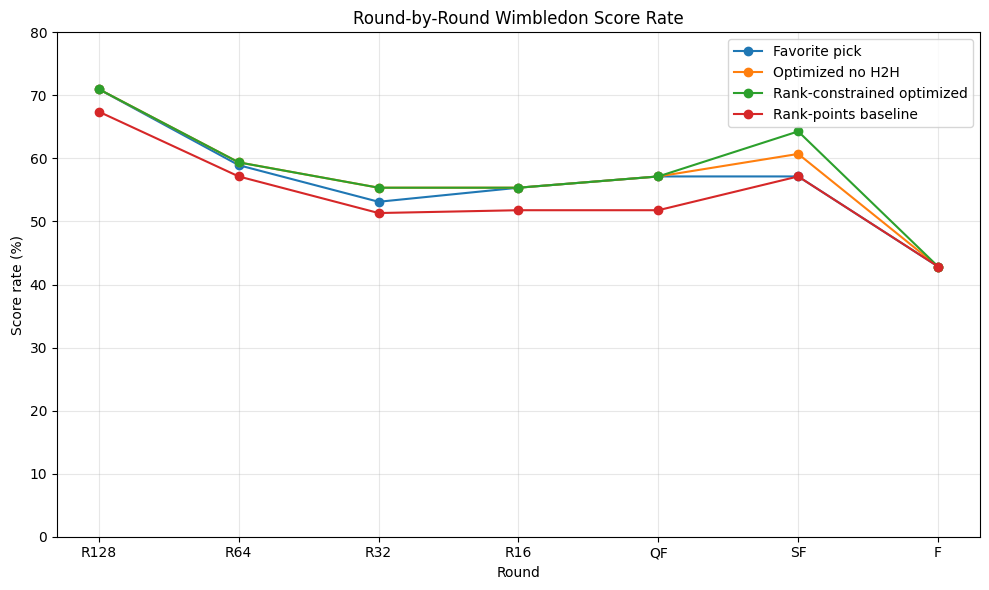

In [275]:
import matplotlib.pyplot as plt

# Make a clean plotting table
plot_df = round_summaries_expanded.copy()

# Convert score_pct to percentage points
plot_df["score_pct_display"] = plot_df["score_pct"] * 100

# Optional: nicer model labels
model_label_map = {
    "rank_constrained_optimized": "Rank-constrained optimized",
    "optimized_no_h2h": "Optimized no H2H",
    "favorite_pick": "Favorite pick",
    "rank_points_baseline": "Rank-points baseline"
}

plot_df["model_label"] = plot_df["model"].map(model_label_map)

# Keep rounds in correct order
plot_df["round"] = pd.Categorical(
    plot_df["round"],
    categories=ROUND_SEQUENCE,
    ordered=True
)

plot_df = plot_df.sort_values(["round", "model_label"])

plt.figure(figsize=(10, 6))

for model_name, model_data in plot_df.groupby("model_label"):
    model_data = model_data.sort_values("round")
    plt.plot(
        model_data["round"],
        model_data["score_pct_display"],
        marker="o",
        label=model_name
    )

plt.title("Round-by-Round Wimbledon Score Rate")
plt.xlabel("Round")
plt.ylabel("Score rate (%)")
plt.ylim(0, 80)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Backtest top 4 contenders constrained brackets - does predicting correct champion always guarentee the most points?

### Generate one bracket constrained to specific champion

In [56]:
def generate_and_score_specific_champion_optimized_bracket(
    match_df,
    neutral_df,
    tournament_name,
    year,
    feature_cols,
    round_points,
    constrained_champion_id
):
    """
    Generates and scores an optimized bracket constrained to a specific champion.
    
    This uses solve_expected_score_bracket(), which already computes the best
    bracket conditional on each possible champion.
    """
    
    root, nodes_by_round = build_tournament_bracket_tree(
        match_df,
        tournament_name,
        year
    )
    
    players = get_tournament_player_features(
        match_df,
        tournament_name,
        year
    )
    
    model = train_model_before_tournament(
        neutral_df,
        tournament_name,
        year,
        feature_cols
    )
    
    root_win_probs, best_by_champion = solve_expected_score_bracket(
        root,
        players,
        model,
        feature_cols,
        round_points
    )
    
    if constrained_champion_id not in best_by_champion:
        raise ValueError("Constrained champion not found in champion options.")
    
    constrained_option = best_by_champion[constrained_champion_id]
    
    picks_df = pd.DataFrame(constrained_option["picks"])
    
    picks_df["year"] = year
    picks_df["tournament"] = tournament_name
    picks_df["constrained_champion_id"] = constrained_champion_id
    picks_df["constrained_champion_name"] = players[constrained_champion_id]["name"]
    picks_df["constrained_champion_prob"] = root_win_probs[constrained_champion_id]
    picks_df["optimized_expected_score"] = constrained_option["expected_score"]
    
    picks_df["correct"] = (
        picks_df["pick_id"] == picks_df["actual_winner_id"]
    )
    
    picks_df["points_possible"] = picks_df["round"].map(round_points)
    
    picks_df["points_earned"] = np.where(
        picks_df["correct"],
        picks_df["points_possible"],
        0
    )
    
    return picks_df, root_win_probs, best_by_champion

### Generate top 4 champion constrained brackets for one tournament

In [57]:
def generate_top_n_champion_constrained_brackets(
    match_df,
    neutral_df,
    tournament_name,
    year,
    feature_cols,
    round_points,
    top_n=4
):
    """
    For a tournament, generates optimized brackets constrained to each of the
    model's top-N championship-probability players.
    """
    
    root, nodes_by_round = build_tournament_bracket_tree(
        match_df,
        tournament_name,
        year
    )
    
    players = get_tournament_player_features(
        match_df,
        tournament_name,
        year
    )
    
    model = train_model_before_tournament(
        neutral_df,
        tournament_name,
        year,
        feature_cols
    )
    
    root_win_probs, best_by_champion = solve_expected_score_bracket(
        root,
        players,
        model,
        feature_cols,
        round_points
    )
    
    champ_probs_df = pd.DataFrame([
        {
            "year": year,
            "tournament": tournament_name,
            "player_id": pid,
            "player_name": players[pid]["name"],
            "championship_prob": prob
        }
        for pid, prob in root_win_probs.items()
    ])
    
    champ_probs_df = champ_probs_df.sort_values(
        "championship_prob",
        ascending=False
    ).reset_index(drop=True)
    
    champ_probs_df["champion_prob_rank"] = champ_probs_df.index + 1
    
    top_champs = champ_probs_df.head(top_n).copy()
    
    all_scored_brackets = []
    all_summaries = []
    
    for _, champ_row in top_champs.iterrows():
        champ_id = champ_row["player_id"]
        champ_rank = champ_row["champion_prob_rank"]
        
        constrained_option = best_by_champion[champ_id]
        
        picks_df = pd.DataFrame(constrained_option["picks"])
        
        picks_df["year"] = year
        picks_df["tournament"] = tournament_name
        picks_df["champion_prob_rank"] = champ_rank
        picks_df["bracket_name"] = f"top_{champ_rank}_champion_constrained"
        picks_df["constrained_champion_id"] = champ_id
        picks_df["constrained_champion_name"] = players[champ_id]["name"]
        picks_df["constrained_champion_prob"] = champ_row["championship_prob"]
        picks_df["optimized_expected_score"] = constrained_option["expected_score"]
        
        picks_df["correct"] = (
            picks_df["pick_id"] == picks_df["actual_winner_id"]
        )
        
        picks_df["points_possible"] = picks_df["round"].map(round_points)
        
        picks_df["points_earned"] = np.where(
            picks_df["correct"],
            picks_df["points_possible"],
            0
        )
        
        champion_row = picks_df[picks_df["round"] == "F"].iloc[0]
        
        summary = {
            "year": year,
            "tournament": tournament_name,
            "champion_prob_rank": champ_rank,
            "bracket_name": f"top_{champ_rank}_champion_constrained",
            "score": picks_df["points_earned"].sum(),
            "possible": picks_df["points_possible"].sum(),
            "score_pct": picks_df["points_earned"].sum() / picks_df["points_possible"].sum(),
            "correct_picks": picks_df["correct"].sum(),
            "total_picks": len(picks_df),
            "pick_accuracy": picks_df["correct"].mean(),
            "predicted_champion": champion_row["pick_name"],
            "actual_champion": champion_row["actual_winner_name"],
            "champion_correct": champion_row["correct"],
            "constrained_champion_name": players[champ_id]["name"],
            "constrained_champion_prob": champ_row["championship_prob"],
            "optimized_expected_score": constrained_option["expected_score"]
        }
        
        all_scored_brackets.append(picks_df)
        all_summaries.append(summary)
    
    scored_brackets_df = pd.concat(all_scored_brackets, ignore_index=True)
    summaries_df = pd.DataFrame(all_summaries)
    
    return summaries_df, scored_brackets_df, champ_probs_df

### Backtest top 4 constrained brackets across expanded Wimbledon years

In [2]:
def backtest_top_n_champion_constrained_brackets(
    match_df,
    neutral_df,
    tournament_name,
    years,
    feature_cols,
    round_points,
    top_n=3
):
    """
    Backtests top-N champion-constrained optimized brackets across years.
    """
    
    all_summaries = []
    all_scored_brackets = []
    all_champ_probs = []
    
    for year in years:
        print(f"Running {tournament_name} {year}...")
        
        summaries_df, scored_df, champ_probs_df = generate_top_n_champion_constrained_brackets(
            match_df=match_df,
            neutral_df=neutral_df,
            tournament_name=tournament_name,
            year=year,
            feature_cols=feature_cols,
            round_points=round_points,
            top_n=top_n
        )
        
        all_summaries.append(summaries_df)
        all_scored_brackets.append(scored_df)
        all_champ_probs.append(champ_probs_df)
    
    results_df = pd.concat(all_summaries, ignore_index=True)
    scored_brackets_df = pd.concat(all_scored_brackets, ignore_index=True)
    champ_probs_df = pd.concat(all_champ_probs, ignore_index=True)
    
    return results_df, scored_brackets_df, champ_probs_df

In [291]:
top4_constrained_results_expanded, top4_constrained_scored_expanded, top4_champ_probs_expanded = backtest_top_n_champion_constrained_brackets(
    match_df=match_df,
    neutral_df=neutral_df,
    tournament_name="Wimbledon",
    years=WIMBLEDON_YEARS_EXPANDED,
    feature_cols=model_feature_cols,
    round_points=round_points,
    top_n=3
)

top4_constrained_results_expanded

Running Wimbledon 2011...
Tournament: Wimbledon
Year: 2011
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Wimbledon 2011
Training cutoff: 2011-06-20 00:00:00
Training matches: 4672
Running Wimbledon 2012...
Tournament: Wimbledon
Year: 2012
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Wimbledon 2012
Training cutoff: 2012-06-25 00:00:00
Training matches: 7798
Running Wimbledon 2013...
Tournament: Wimbledon
Year: 2013
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Wimbledon 2013
Training cutoff: 2013-06-24 00:00:00
Training matches: 10760
Running Wimbledon 2014...
Tournament: Wimbledon
Year: 2014
Matches found: 127
Surface: ['Grass']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament

,year,tournament,champion_prob_rank,bracket_name,score,possible,score_pct,correct_picks,total_picks,pick_accuracy,predicted_champion,actual_champion,champion_correct,constrained_champion_name,constrained_champion_prob,optimized_expected_score
0,2011,Wimbledon,1,top_1_champion_constrained,2750,4480,0.613839,89,127,0.700787,Rafael Nadal,Novak Djokovic,False,Rafael Nadal,0.323112,2537.671236
1,2011,Wimbledon,2,top_2_champion_constrained,3390,4480,0.756696,90,127,0.708661,Novak Djokovic,Novak Djokovic,True,Novak Djokovic,0.276134,2507.605535
2,2011,Wimbledon,3,top_3_champion_constrained,2430,4480,0.542411,88,127,0.692913,Roger Federer,Novak Djokovic,False,Roger Federer,0.197828,2429.262972
3,2012,Wimbledon,1,top_1_champion_constrained,2090,4480,0.466518,83,127,0.653543,Novak Djokovic,Roger Federer,False,Novak Djokovic,0.256630,2383.678853
4,2012,Wimbledon,2,top_2_champion_constrained,3050,4480,0.680804,85,127,0.669291,Roger Federer,Roger Federer,True,Roger Federer,0.229601,2357.357098
5,2012,Wimbledon,3,top_3_champion_constrained,2090,4480,0.466518,83,127,0.653543,Rafael Nadal,Roger Federer,False,Rafael Nadal,0.221324,2361.083361
6,2013,Wimbledon,1,top_1_champion_constrained,2370,4480,0.529018,73,127,0.574803,Novak Djokovic,Andy Murray,False,Novak Djokovic,0.294476,2415.865603
7,2013,Wimbledon,2,top_2_champion_constrained,2050,4480,0.457589,72,127,0.566929,Rafael Nadal,Andy Murray,False,Rafael Nadal,0.178071,2341.362489
8,2013,Wimbledon,3,top_3_champion_constrained,3010,4480,0.671875,74,127,0.582677,Andy Murray,Andy Murray,True,Andy Murray,0.169740,2336.034629
9,2014,Wimbledon,1,top_1_champion_constrained,2880,4480,0.642857,86,127,0.677165,Novak Djokovic,Novak Djokovic,True,Novak Djokovic,0.380512,2446.635447


### Avg score by champion-probability rank

In [292]:
top4_rank_summary = top4_constrained_results_expanded.groupby(
    "champion_prob_rank"
).agg(
    avg_score=("score", "mean"),
    avg_score_pct=("score_pct", "mean"),
    avg_pick_accuracy=("pick_accuracy", "mean"),
    champion_accuracy=("champion_correct", "mean"),
    avg_champion_prob=("constrained_champion_prob", "mean")
).reset_index()

top4_rank_summary

,champion_prob_rank,avg_score,avg_score_pct,avg_pick_accuracy,champion_accuracy,avg_champion_prob
0,1,2571.428571,0.573980,0.642857,0.428571,0.349886
1,2,2480.000000,0.553571,0.641732,0.285714,0.213785
2,3,2434.285714,0.543367,0.640607,0.285714,0.146487


### Did we capture the champion each year?

In [293]:
top4_portfolio_by_year = top4_constrained_results_expanded.groupby(
    ["year", "tournament"]
).agg(
    best_score_among_4=("score", "max"),
    avg_score_among_4=("score", "mean"),
    worst_score_among_4=("score", "min"),
    any_champion_correct=("champion_correct", "max"),
    best_pick_accuracy_among_4=("pick_accuracy", "max"),
    avg_pick_accuracy_among_4=("pick_accuracy", "mean")
).reset_index()

top4_portfolio_by_year["any_champion_correct"] = (
    top4_portfolio_by_year["any_champion_correct"].astype(bool)
)

top4_portfolio_by_year

,year,tournament,best_score_among_4,avg_score_among_4,worst_score_among_4,any_champion_correct,best_pick_accuracy_among_4,avg_pick_accuracy_among_4
0,2011,Wimbledon,3390,2856.666667,2430,True,0.708661,0.700787
1,2012,Wimbledon,3050,2410.000000,2090,True,0.669291,0.658793
2,2013,Wimbledon,3010,2476.666667,2050,True,0.582677,0.574803
3,2014,Wimbledon,2880,2560.000000,2240,True,0.677165,0.674541
4,2015,Wimbledon,3400,2866.666667,2440,True,0.692913,0.685039
5,2016,Wimbledon,2890,2463.333333,2250,True,0.692913,0.687664
6,2017,Wimbledon,2910,2376.666667,1950,True,0.677165,0.669291
7,2018,Wimbledon,2770,2130.000000,1810,True,0.606299,0.595801
8,2019,Wimbledon,3210,2676.666667,2250,True,0.653543,0.645669
9,2021,Wimbledon,2580,2153.333333,1940,True,0.637795,0.632546


In [294]:
top4_portfolio_summary = pd.Series({
    "avg_best_score_among_4": top4_portfolio_by_year["best_score_among_4"].mean(),
    "avg_score_across_all_4": top4_portfolio_by_year["avg_score_among_4"].mean(),
    "avg_worst_score_among_4": top4_portfolio_by_year["worst_score_among_4"].mean(),
    "champion_covered_rate": top4_portfolio_by_year["any_champion_correct"].mean(),
    "avg_best_pick_accuracy_among_4": top4_portfolio_by_year["best_pick_accuracy_among_4"].mean(),
    "avg_pick_accuracy_across_all_4": top4_portfolio_by_year["avg_pick_accuracy_among_4"].mean()
})

top4_portfolio_summary

avg_best_score_among_4            3028.571429
avg_score_across_all_4            2495.238095
avg_worst_score_among_4           2137.142857
champion_covered_rate                1.000000
avg_best_pick_accuracy_among_4       0.649606
avg_pick_accuracy_across_all_4       0.641732
dtype: float64

### Which champion probability rank was the actual champion?

In [295]:
actual_champion_rank_by_year = top4_constrained_results_expanded[
    top4_constrained_results_expanded["champion_correct"]
][[
    "year",
    "actual_champion",
    "champion_prob_rank",
    "constrained_champion_name",
    "constrained_champion_prob",
    "score"
]].sort_values("year")

actual_champion_rank_by_year

,year,actual_champion,champion_prob_rank,constrained_champion_name,constrained_champion_prob,score
1,2011,Novak Djokovic,2,Novak Djokovic,0.276134,3390
4,2012,Roger Federer,2,Roger Federer,0.229601,3050
8,2013,Andy Murray,3,Andy Murray,0.169740,3010
9,2014,Novak Djokovic,1,Novak Djokovic,0.380512,2880
12,2015,Novak Djokovic,1,Novak Djokovic,0.389570,3400
16,2016,Andy Murray,2,Andy Murray,0.281009,2890
18,2017,Roger Federer,1,Roger Federer,0.258297,2910
23,2018,Novak Djokovic,3,Novak Djokovic,0.101617,2770
24,2019,Novak Djokovic,1,Novak Djokovic,0.311117,3210
27,2021,Novak Djokovic,1,Novak Djokovic,0.413022,2580


In [296]:
actual_champion_rank_counts = actual_champion_rank_by_year[
    "champion_prob_rank"
].value_counts().sort_index()

actual_champion_rank_counts

champion_prob_rank
1    6
2    4
3    4
Name: count, dtype: int64

There is complete coverage over the past 14 Wimbledons of the top 3 favorites, and the bracket that predicts the correct chmapion is the one that returns the most points, so I will submit 3 brackets, one per constrained champion

Next step is to make the file that takes in the draw and outputs the top 3 constrained brackets

## Backtest on French Open 2026 because it was so crazy

In [58]:
RG_TOURNAMENT_NAME = "Roland Garros"
RG_YEAR = 2026

rg_2026_top3_results, rg_2026_top3_scored, rg_2026_champ_probs = backtest_top_n_champion_constrained_brackets(
    match_df=match_df,
    neutral_df=neutral_df,
    tournament_name=RG_TOURNAMENT_NAME,
    years=[RG_YEAR],
    feature_cols=model_feature_cols,
    round_points=round_points,
    top_n=3
)

rg_2026_top3_results

Running Roland Garros 2026...
Tournament: Roland Garros
Year: 2026
Matches found: 127
Surface: ['Clay']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Roland Garros 2026
Training cutoff: 2026-05-24 00:00:00
Training matches: 46893


,year,tournament,champion_prob_rank,bracket_name,score,possible,score_pct,correct_picks,total_picks,pick_accuracy,predicted_champion,actual_champion,champion_correct,constrained_champion_name,constrained_champion_prob,optimized_expected_score
0,2026,Roland Garros,1,top_1_champion_constrained,1240,4480,0.276786,65,127,0.511811,Jannik Sinner,Alexander Zverev,False,Jannik Sinner,0.598183,2307.269910
1,2026,Roland Garros,2,top_2_champion_constrained,1240,4480,0.276786,65,127,0.511811,Novak Djokovic,Alexander Zverev,False,Novak Djokovic,0.105205,1991.764164
2,2026,Roland Garros,3,top_3_champion_constrained,2200,4480,0.491071,67,127,0.527559,Alexander Zverev,Alexander Zverev,True,Alexander Zverev,0.079509,1961.828176


### As expected, the best bracket would have placed 78/3402 (top 2% still), but not even close to winning (3090)

## Australian Open Test

In [59]:
RG_TOURNAMENT_NAME = "Australian Open"
RG_YEAR = 2026

rg_2026_top3_results, rg_2026_top3_scored, rg_2026_champ_probs = backtest_top_n_champion_constrained_brackets(
    match_df=match_df,
    neutral_df=neutral_df,
    tournament_name=RG_TOURNAMENT_NAME,
    years=[RG_YEAR],
    feature_cols=model_feature_cols,
    round_points=round_points,
    top_n=3
)

rg_2026_top3_results

Running Australian Open 2026...
Tournament: Australian Open
Year: 2026
Matches found: 127
Surface: ['Hard']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: Australian Open 2026
Training cutoff: 2026-01-18 00:00:00
Training matches: 45753


,year,tournament,champion_prob_rank,bracket_name,score,possible,score_pct,correct_picks,total_picks,pick_accuracy,predicted_champion,actual_champion,champion_correct,constrained_champion_name,constrained_champion_prob,optimized_expected_score
0,2026,Australian Open,1,top_1_champion_constrained,2530,4480,0.564732,83,127,0.653543,Jannik Sinner,Carlos Alcaraz,False,Jannik Sinner,0.468924,2430.172258
1,2026,Australian Open,2,top_2_champion_constrained,3170,4480,0.707589,84,127,0.661417,Carlos Alcaraz,Carlos Alcaraz,True,Carlos Alcaraz,0.255509,2293.586820
2,2026,Australian Open,3,top_3_champion_constrained,2850,4480,0.636161,84,127,0.661417,Novak Djokovic,Carlos Alcaraz,False,Novak Djokovic,0.094415,2044.749454


## US Open Test

In [62]:
RG_TOURNAMENT_NAME = "US Open"
RG_YEAR = 2025

rg_2026_top3_results, rg_2026_top3_scored, rg_2026_champ_probs = backtest_top_n_champion_constrained_brackets(
    match_df=match_df,
    neutral_df=neutral_df,
    tournament_name=RG_TOURNAMENT_NAME,
    years=[RG_YEAR],
    feature_cols=model_feature_cols,
    round_points=round_points,
    top_n=3
)

rg_2026_top3_results

Running US Open 2025...
Tournament: US Open
Year: 2025
Matches found: 127
Surface: ['Hard']
Round counts: {'R128': 64, 'R64': 32, 'R32': 16, 'R16': 8, 'QF': 4, 'SF': 2, 'F': 1}
Tournament: US Open 2025
Training cutoff: 2025-08-24 00:00:00
Training matches: 44865


,year,tournament,champion_prob_rank,bracket_name,score,possible,score_pct,correct_picks,total_picks,pick_accuracy,predicted_champion,actual_champion,champion_correct,constrained_champion_name,constrained_champion_prob,optimized_expected_score
0,2025,US Open,1,top_1_champion_constrained,2590,4480,0.578125,77,127,0.606299,Jannik Sinner,Carlos Alcaraz,False,Jannik Sinner,0.396978,2401.132178
1,2025,US Open,2,top_2_champion_constrained,3230,4480,0.720982,78,127,0.614173,Carlos Alcaraz,Carlos Alcaraz,True,Carlos Alcaraz,0.228350,2293.209700
2,2025,US Open,3,top_3_champion_constrained,2270,4480,0.506696,76,127,0.598425,Novak Djokovic,Carlos Alcaraz,False,Novak Djokovic,0.101336,2149.290855
